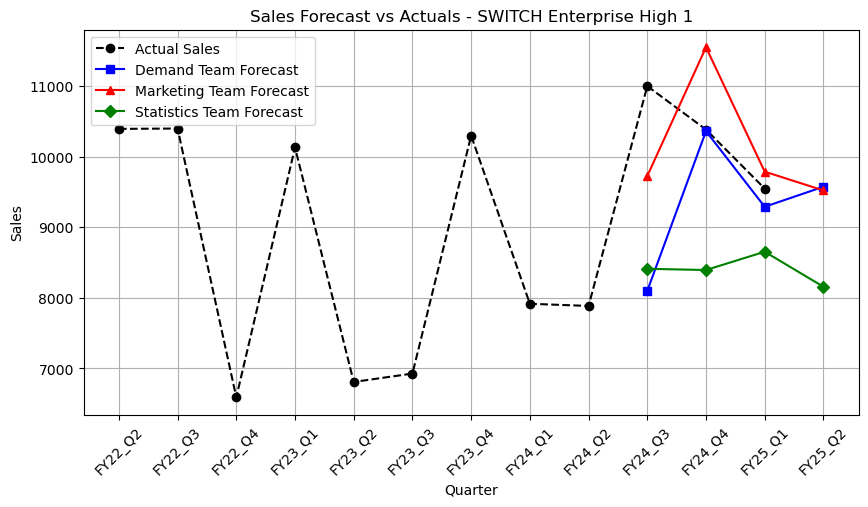

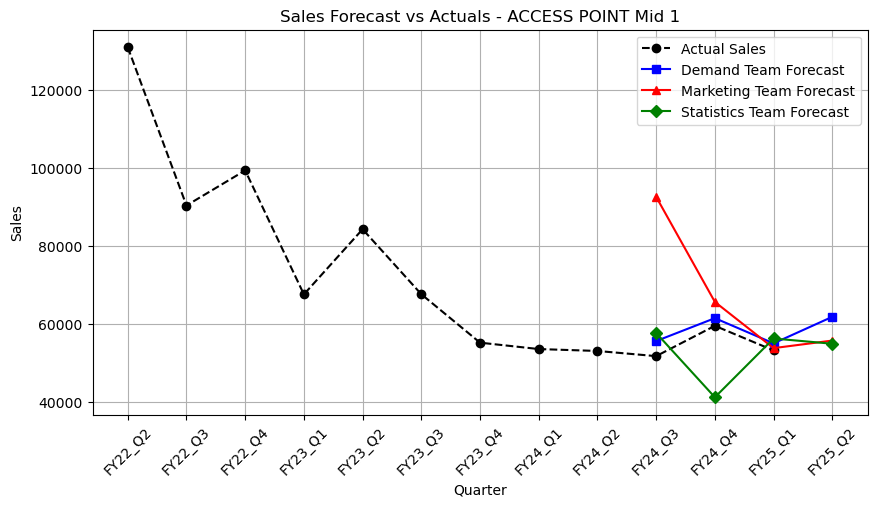

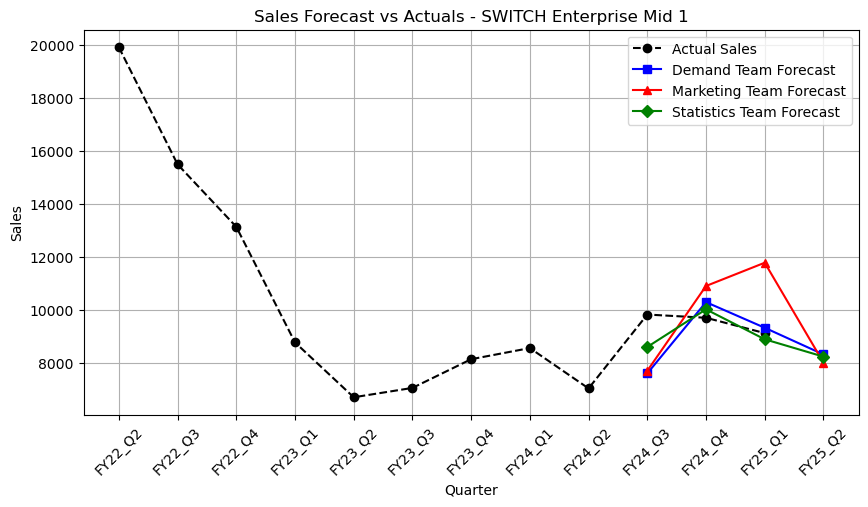

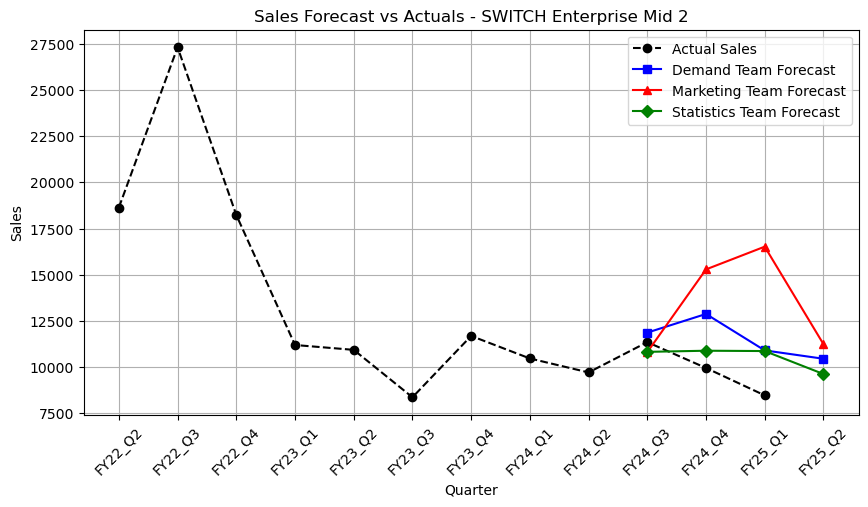

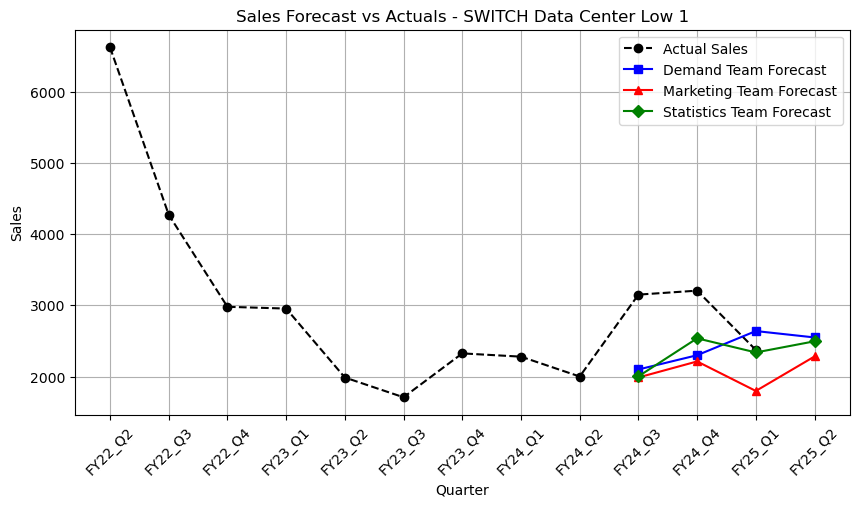

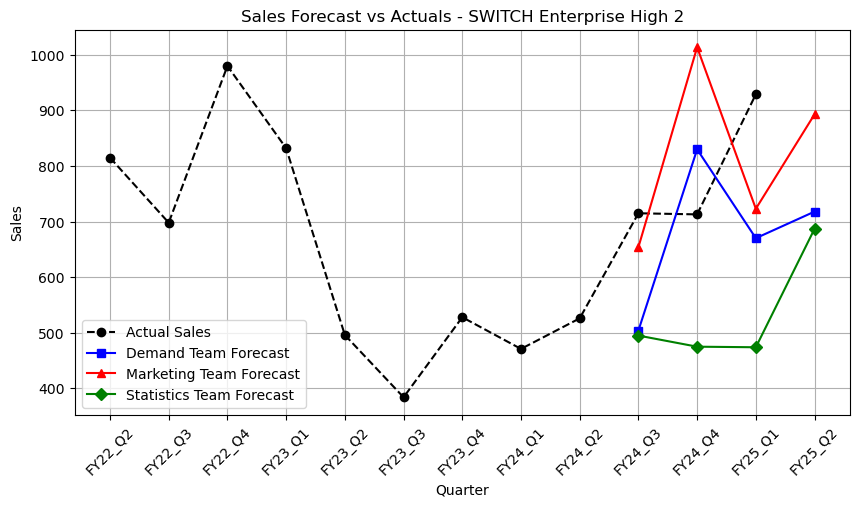

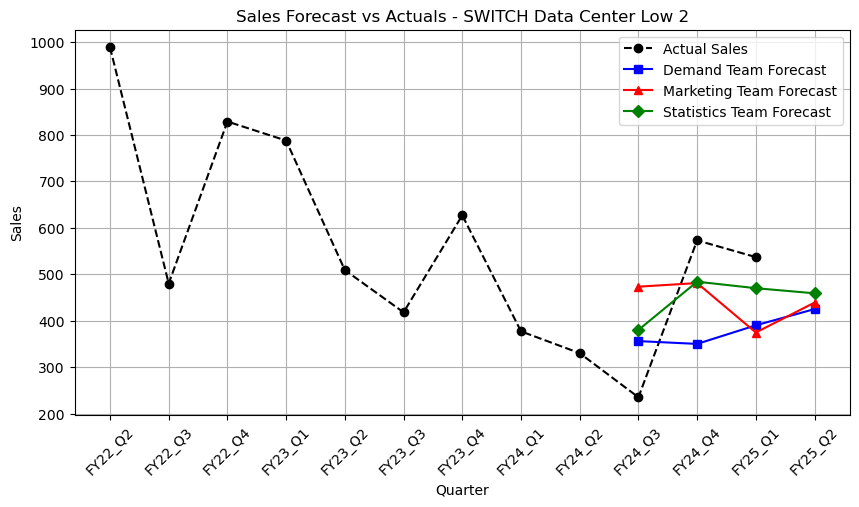

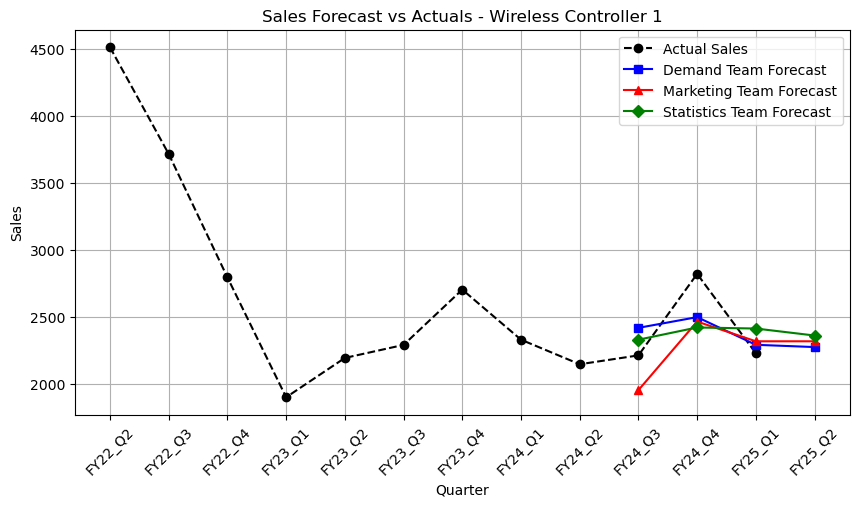

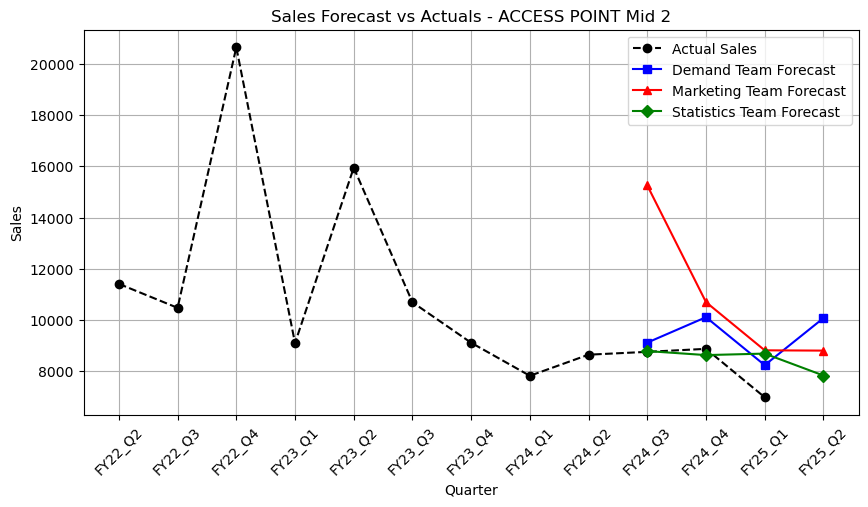

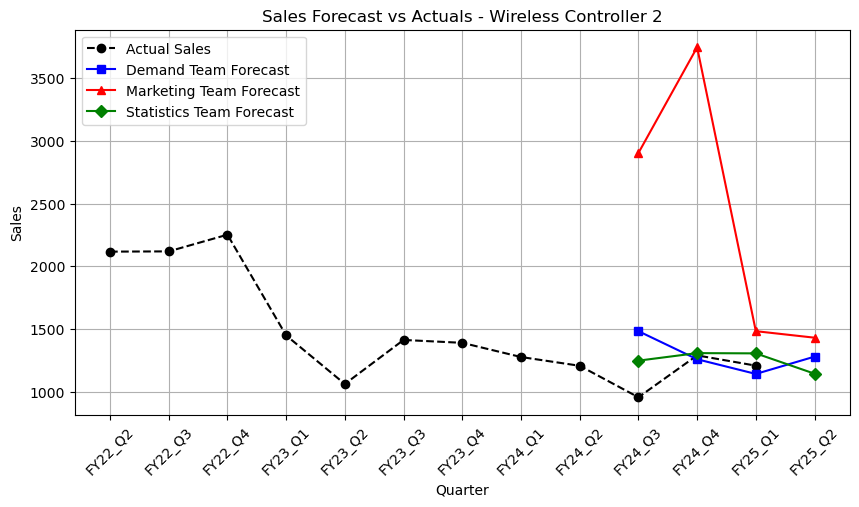

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("forecasted_values.csv")

# Define actual sales and forecasted columns
actual_columns = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1', 'FY23_Q2', 'FY23_Q3',
                  'FY23_Q4', 'FY24_Q1', 'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']
forecast_columns = {
    "D": ["D_FY24_Q3_Forecasted", "D_FY24_Q4_Forecasted", "D_FY25_Q1_Forecasted", "D_FY2025_Q2_Forecasted"],
    "M": ["M_FY24_Q3_Forecasted", "M_FY24_Q4_Forecasted", "M_FY25_Q1_Forecasted", "M_FY2025_Q2_Forecasted"],
    "S": ["S_FY24_Q3_Forecasted", "S_FY24_Q4_Forecasted", "S_FY25_Q1_Forecasted", "S_FY2025_Q2_Forecasted"]
}

# Plot for each product (only first row if duplicates exist)
for product in df["Product_Name"].unique():
    product_data = df[df["Product_Name"] == product].iloc[0]  # Take first row only

    # Extract actual sales data
    actual_sales = product_data[actual_columns].values.flatten()
    
    # Extract forecasted values (only last 4 quarters)
    forecast_D = product_data[forecast_columns["D"]].values.flatten()
    forecast_M = product_data[forecast_columns["M"]].values.flatten()
    forecast_S = product_data[forecast_columns["S"]].values.flatten()

    # Create x-axis labels: first 12 for actuals + last 4 for forecasts
    x_labels_actual = actual_columns
    x_labels_forecast = ["FY24_Q3", "FY24_Q4", "FY25_Q1", "FY25_Q2"]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_labels_actual, actual_sales, marker="o", label="Actual Sales", color="black", linestyle="dashed")
    plt.plot(x_labels_forecast, forecast_D, marker="s", label="Demand Team Forecast", color="blue")
    plt.plot(x_labels_forecast, forecast_M, marker="^", label="Marketing Team Forecast", color="red")
    plt.plot(x_labels_forecast, forecast_S, marker="D", label="Statistics Team Forecast", color="green")

    # Formatting
    plt.xticks(rotation=45)
    plt.xlabel("Quarter")
    plt.ylabel("Sales")
    plt.title(f"Sales Forecast vs Actuals - {product}")
    plt.legend()
    plt.grid(True)
    plt.show()


,Cost_Rank,Product_Name,Product_Life_Cycle,FY22_Q2,FY22_Q3,FY22_Q4,FY23_Q1,FY23_Q2,FY23_Q3,FY23_Q4,...,S_FY2025_Q2_Forecasted,D_FY24_Q3_Forecasted,D_FY24_Q4_Forecasted,D_FY25_Q1_Forecasted,M_FY24_Q3_Forecasted,M_FY24_Q4_Forecasted,M_FY25_Q1_Forecasted,S_FY24_Q3_Forecasted,S_FY24_Q4_Forecasted,S_FY25_Q1_Forecasted
0,1,SWITCH Enterprise High 1,Sustaining,10395,10400,6592,10132,6809,6928,10299,...,8158,8100.0363,10362.1530,9291.1770,9727.0842,11551.2355,9788.6799,8412.4647,8395.2340,8654.2587
1,2,ACCESS POINT Mid 1,Decline,131048,90440,99442,67630,84349,67670,55237,...,54959,55649.0407,61525.4800,55060.6545,92662.0995,65694.6800,53836.0195,57720.2807,41221.4760,56306.5875
2,3,SWITCH Enterprise Mid 1,Sustaining,19897,15482,13128,8770,6703,7056,8138,...,8235,7602.2280,10289.7600,9323.5962,7701.4302,10897.9500,11775.5898,8599.1610,10018.1600,8889.3890
3,4,SWITCH Enterprise Mid 2,Sustaining,18638,27319,18233,11190,10927,8358,11681,...,9618,11861.1975,12871.1186,10897.7680,10802.7090,15286.0074,16517.5642,10818.5920,10879.9294,10862.2318
4,5,SWITCH Data Center Low 1,Sustaining,6629,4275,2981,2956,1987,1709,2326,...,2496,2099.8624,2300.1360,2639.8880,1987.6512,2212.8784,1797.8302,2003.0960,2537.8488,2339.1022


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cost_Rank               10 non-null     int64  
 1   Product_Name            10 non-null     object 
 2   Product_Life_Cycle      10 non-null     object 
 3   FY22_Q2                 10 non-null     int64  
 4   FY22_Q3                 10 non-null     int64  
 5   FY22_Q4                 10 non-null     int64  
 6   FY23_Q1                 10 non-null     int64  
 7   FY23_Q2                 10 non-null     int64  
 8   FY23_Q3                 10 non-null     int64  
 9   FY23_Q4                 10 non-null     int64  
 10  FY24_Q1                 10 non-null     int64  
 11  FY24_Q2                 10 non-null     int64  
 12  FY24_Q3                 10 non-null     int64  
 13  FY24_Q4                 10 non-null     int64  
 14  FY25_Q1                 10 non-null     int64

None

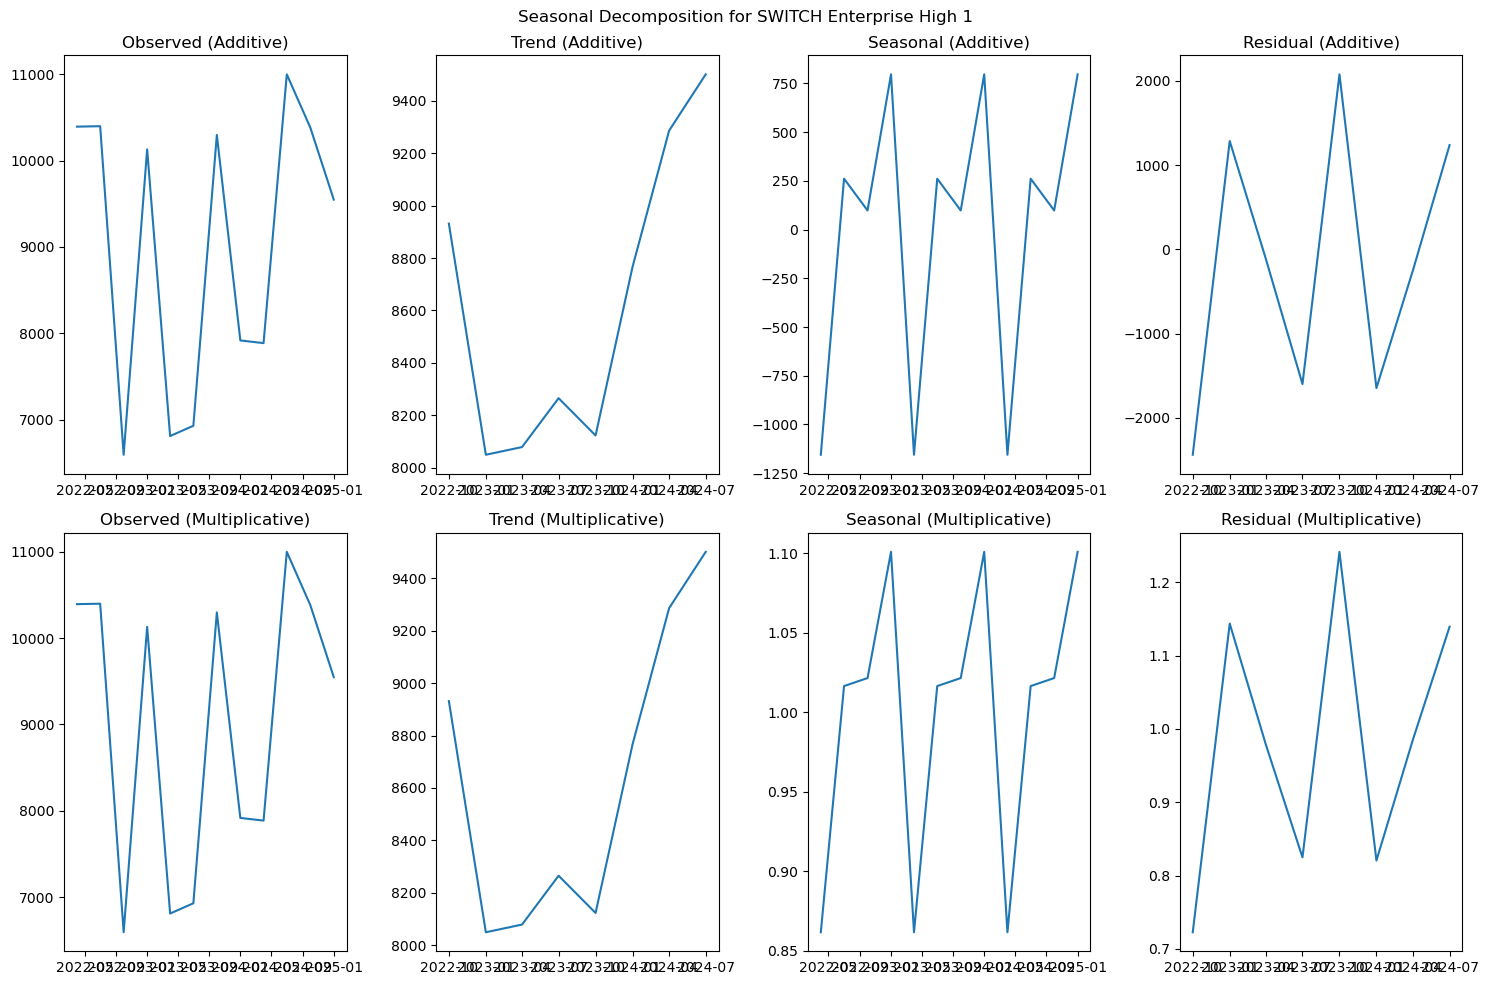

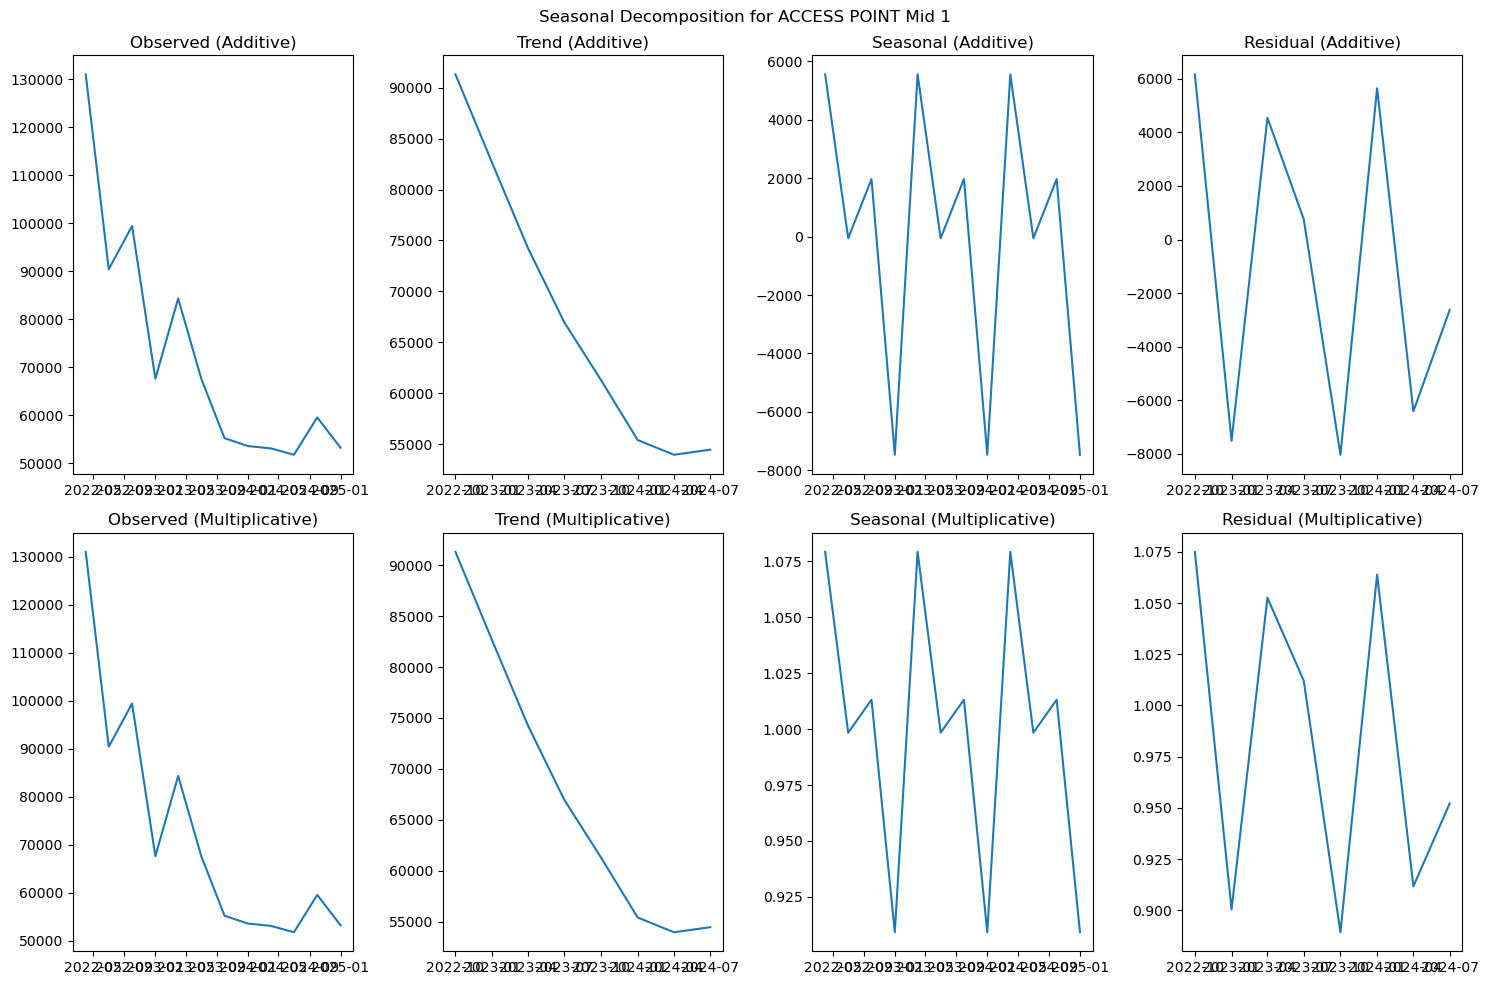

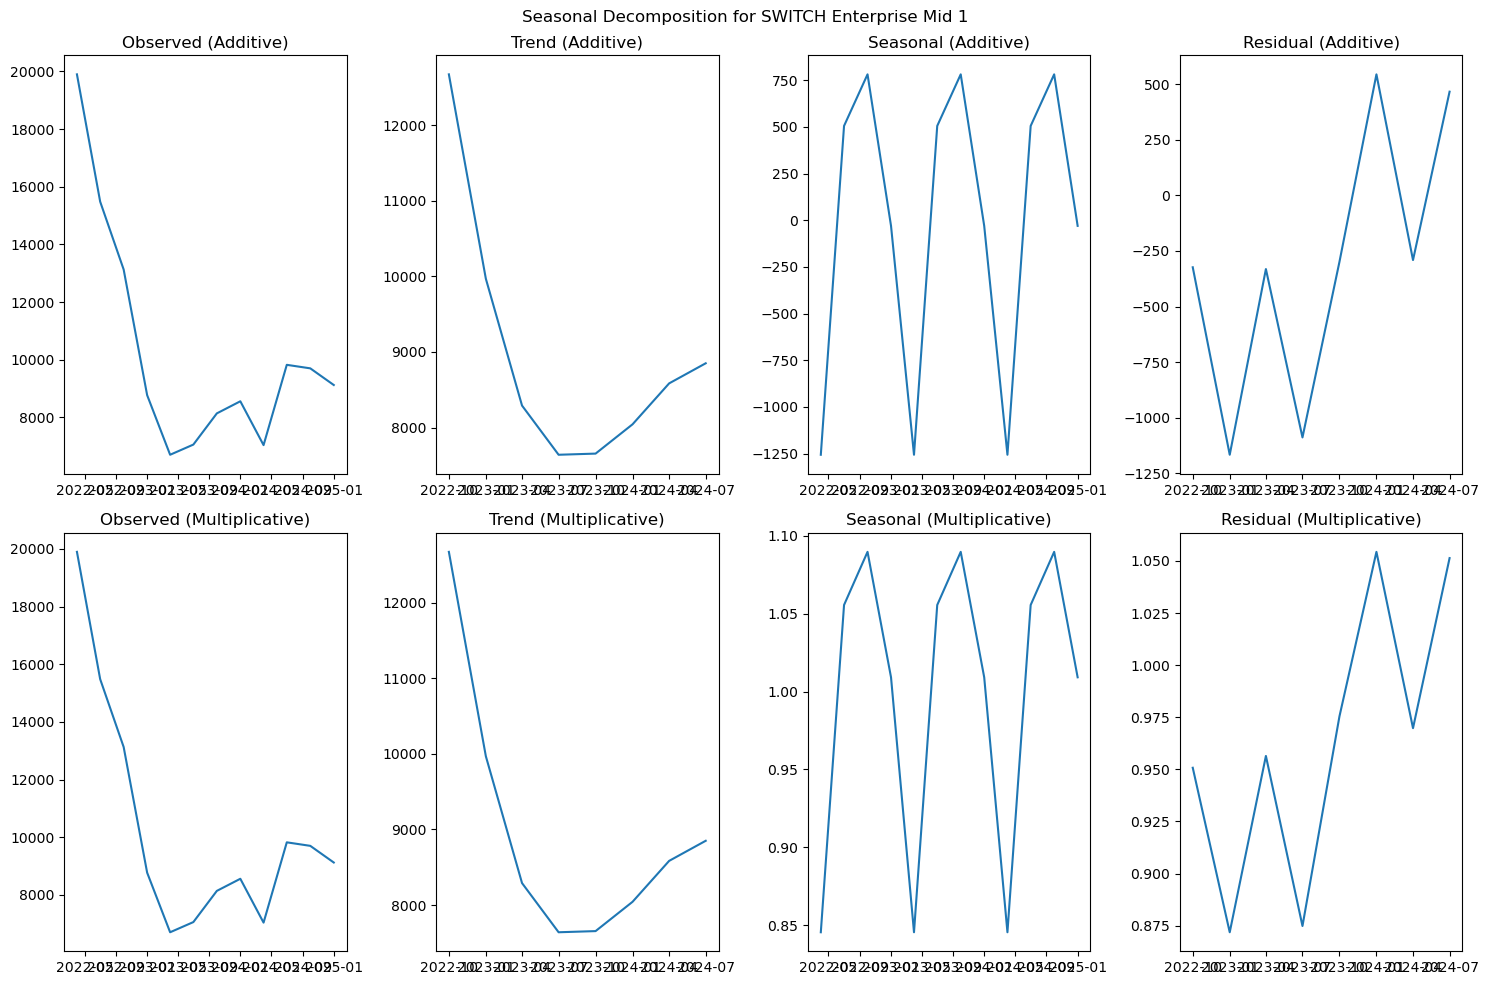

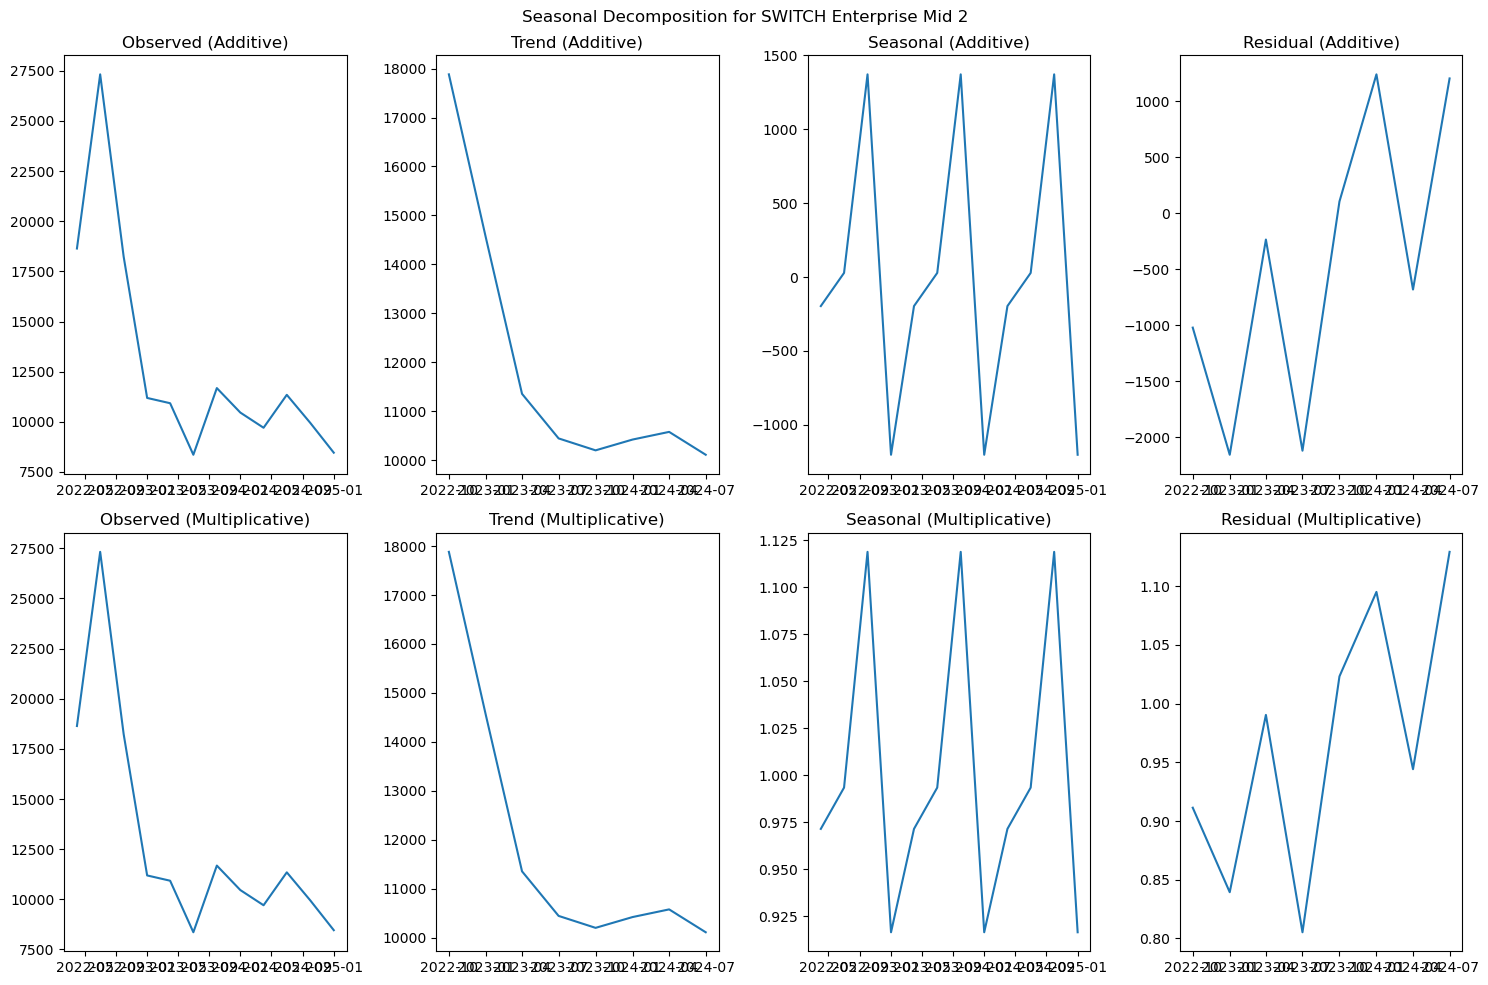

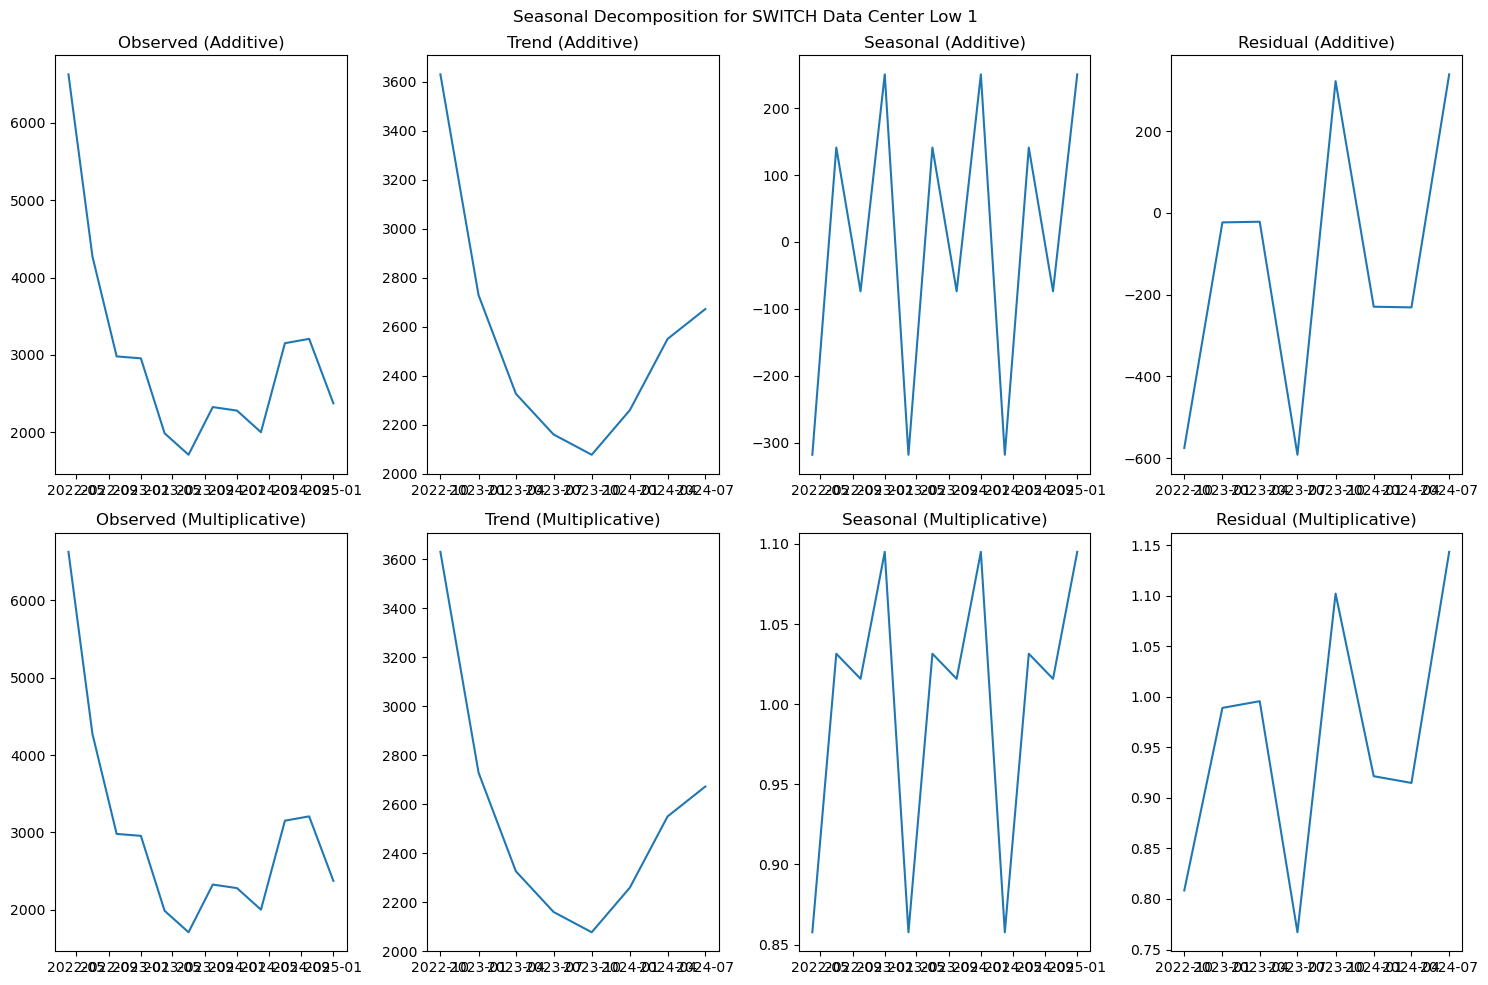

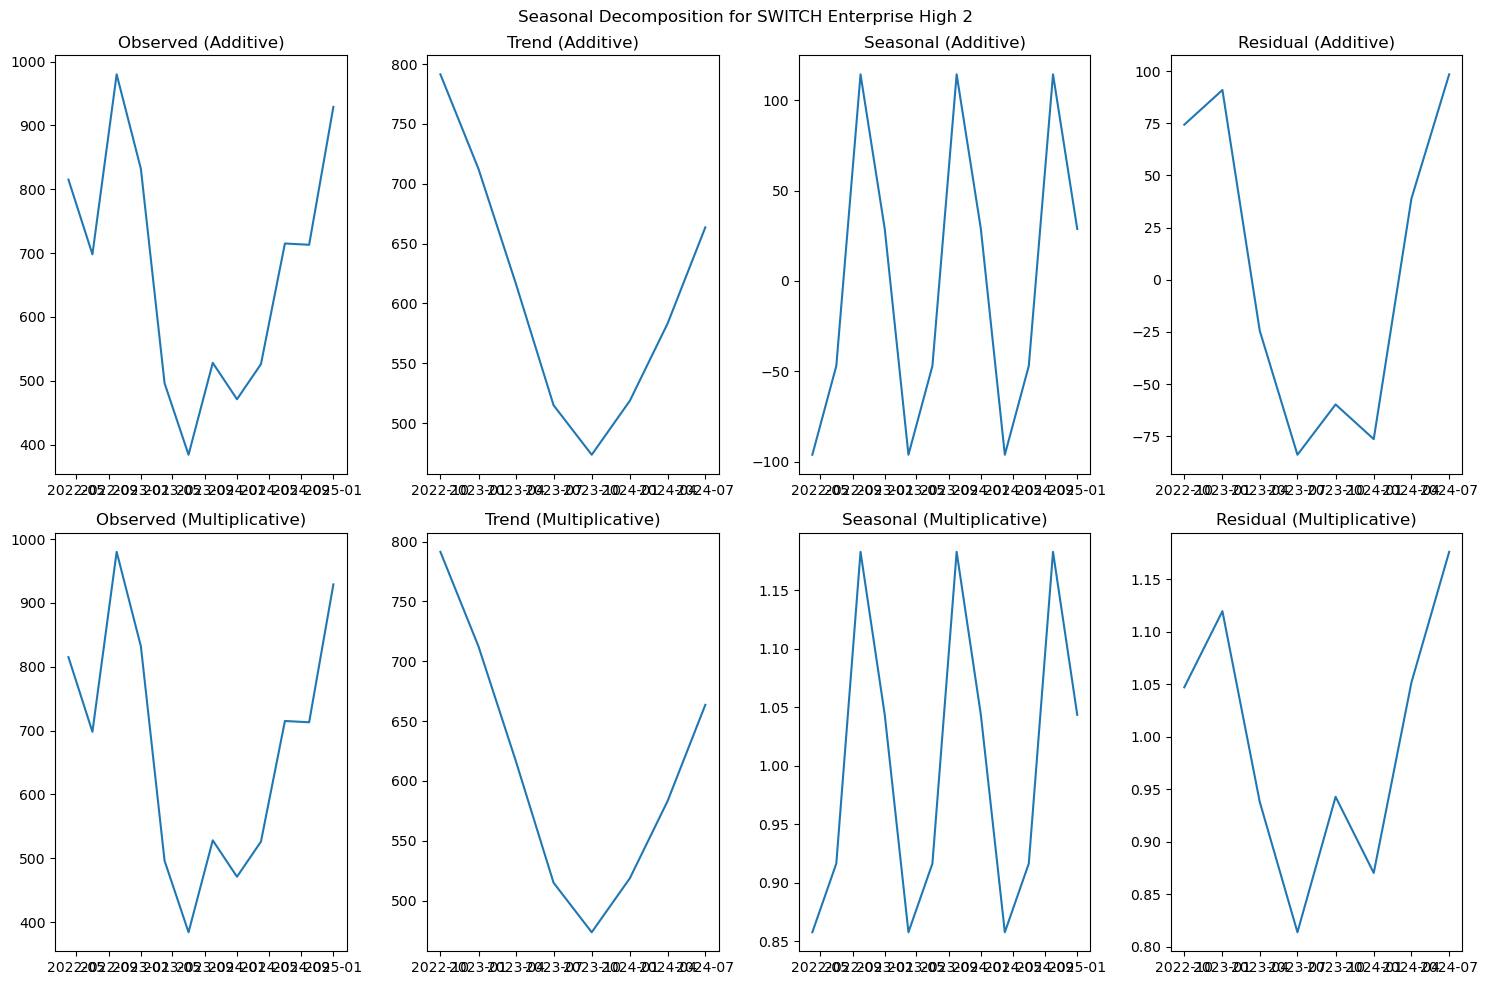

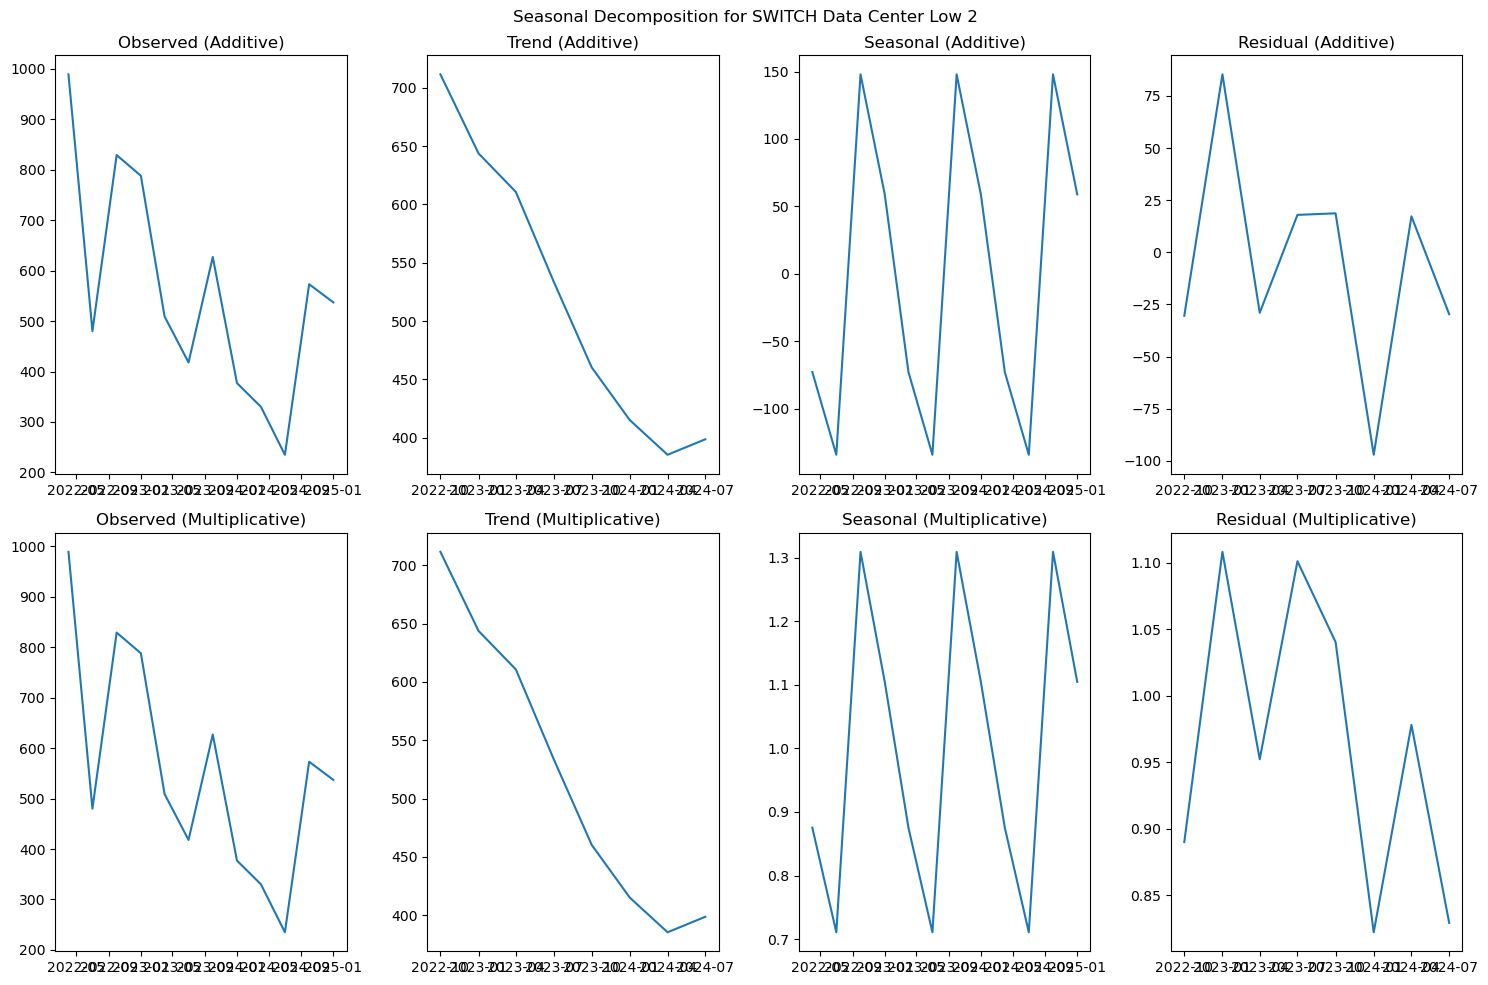

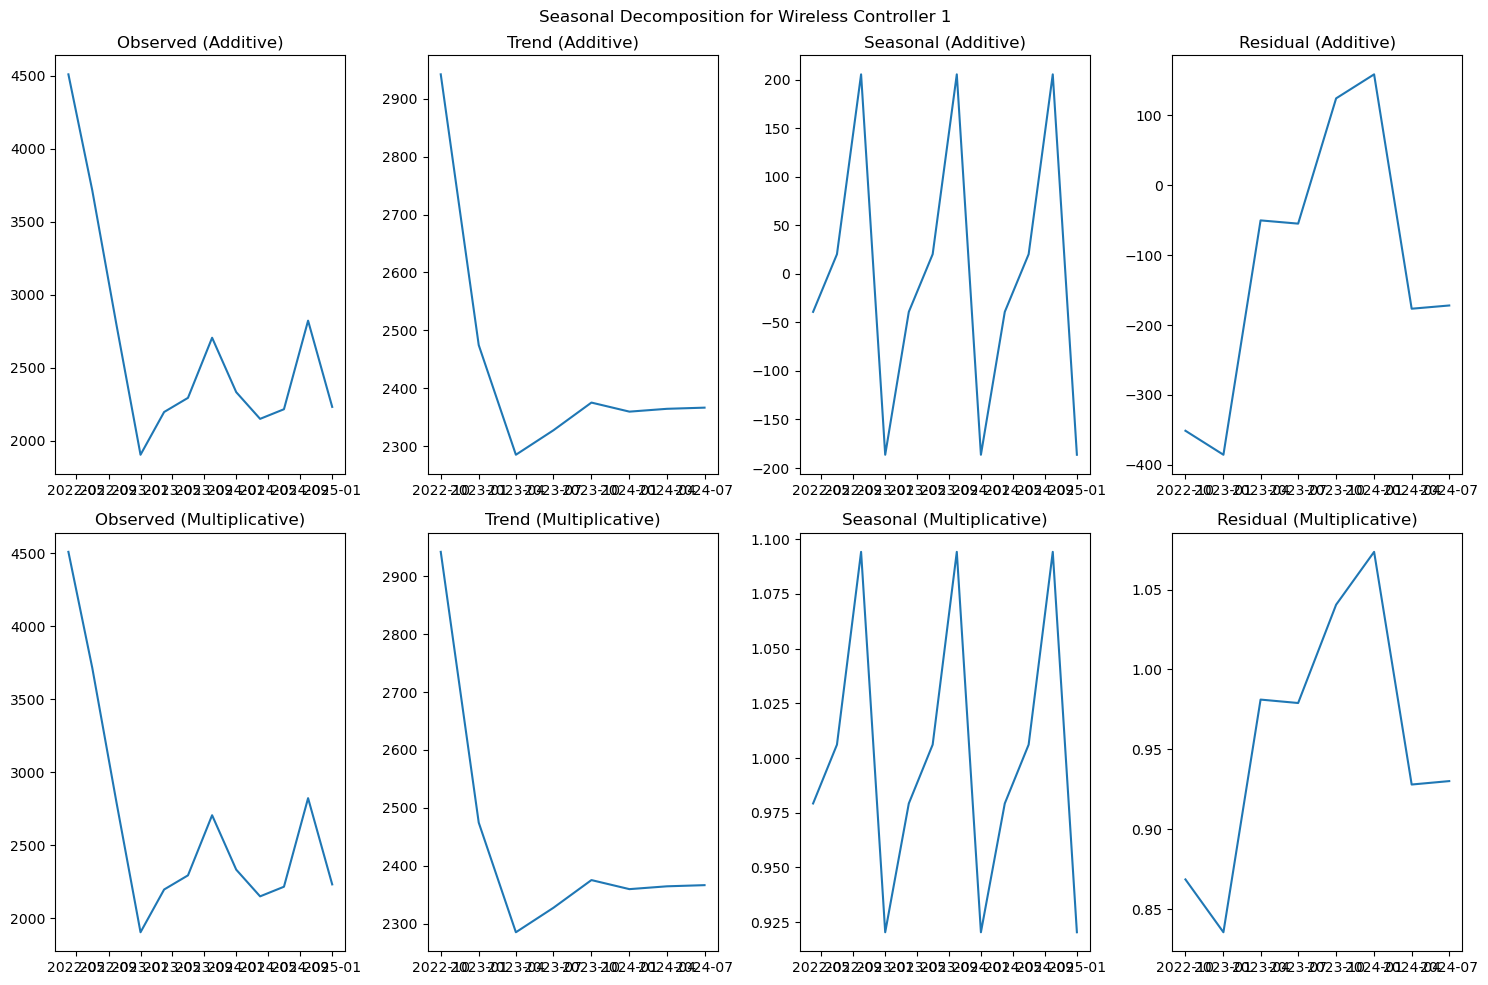

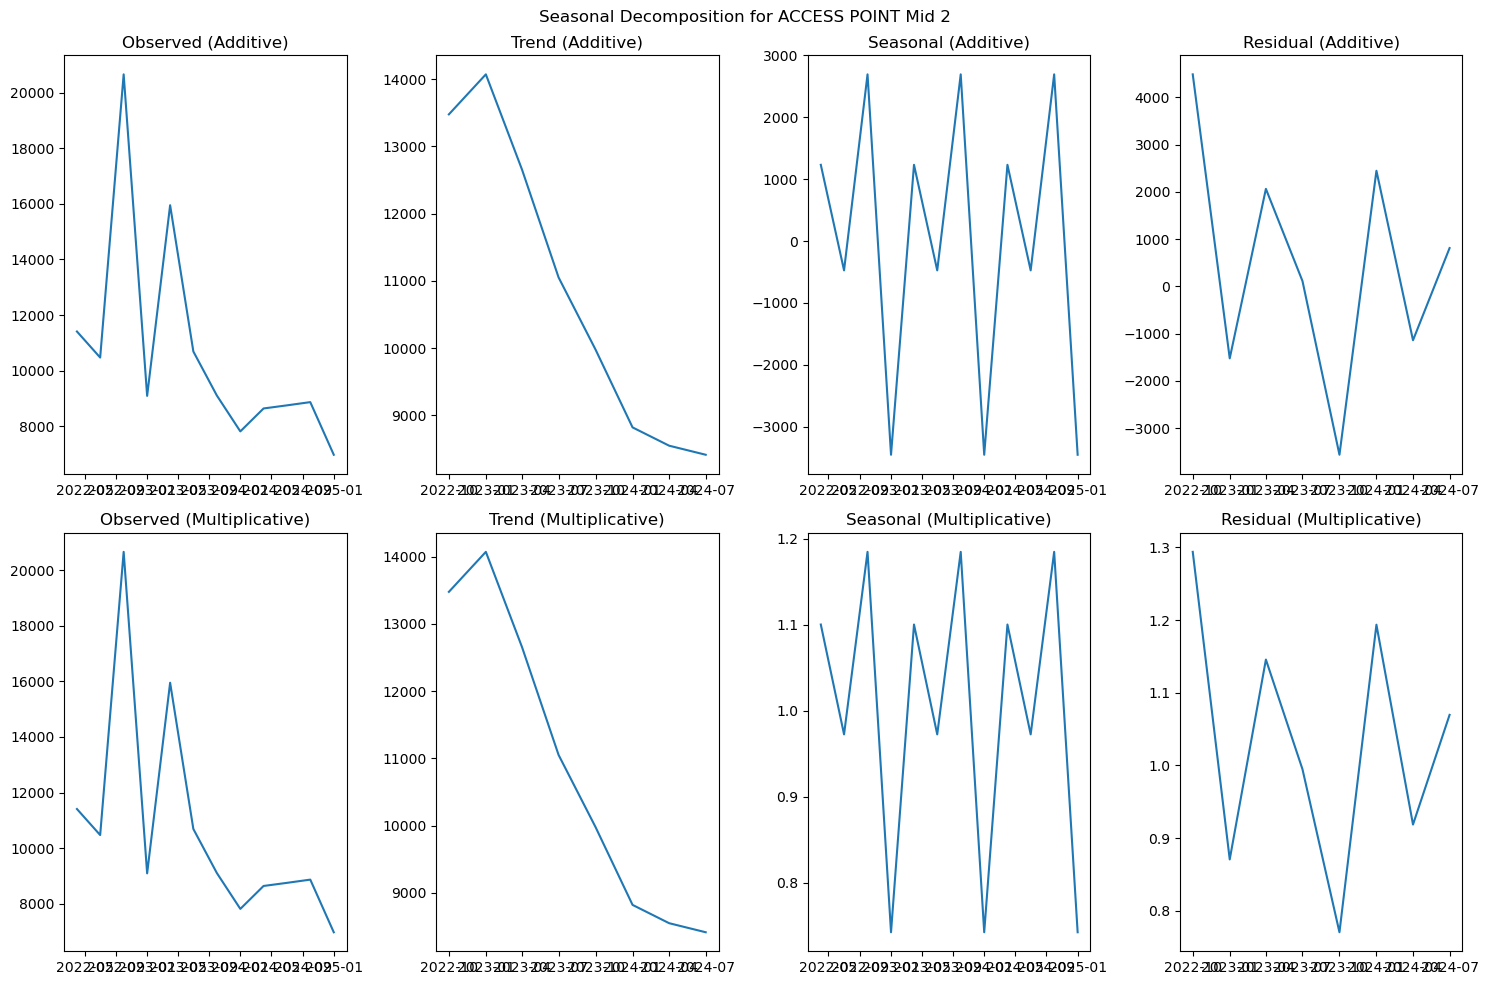

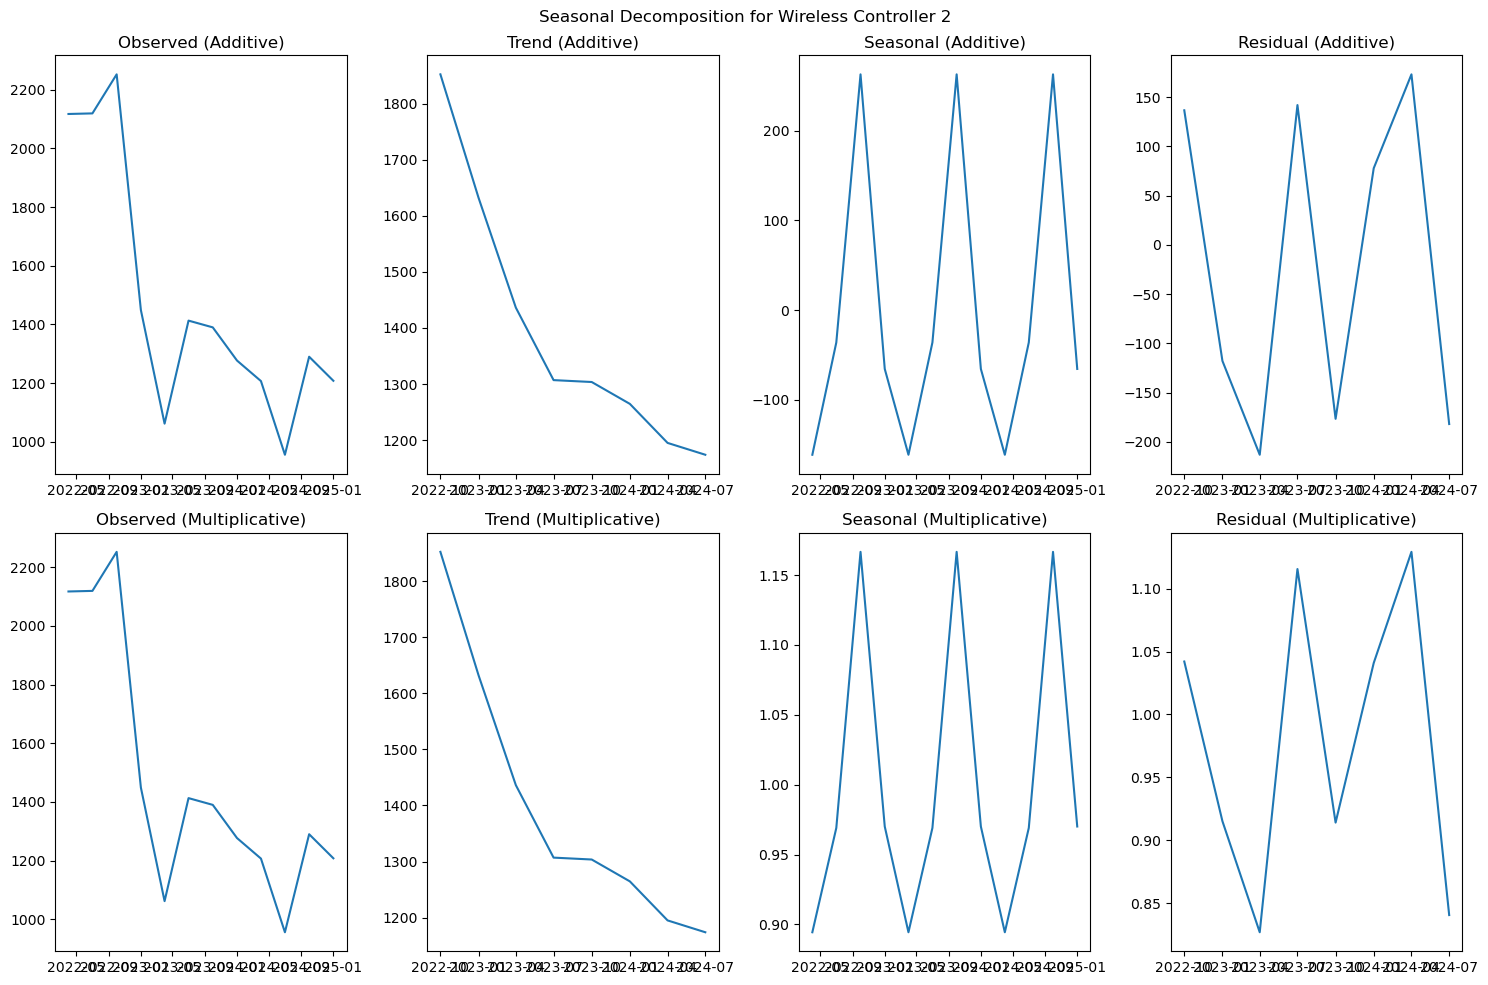

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the dataset
file_path = 'forecasted_values.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
display(df.head())
display(df.info())

# Select 10 products
selected_products = df['Product_Name'].unique()[:10]
df_filtered = df[df['Product_Name'].isin(selected_products)]

# Extract relevant columns (last 12 quarters)
quarters = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1', 'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1', 'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']
df_filtered = df_filtered[['Product_Name'] + quarters]

# Reshape the data into a time series format
df_melted = df_filtered.melt(id_vars=['Product_Name'], var_name='Quarter', value_name='Sales')

# Convert fiscal quarter format into a proper date index
def convert_fy_quarter(fy_quarter):
    year = int(fy_quarter[2:4]) + 2000  # Extract fiscal year
    quarter = int(fy_quarter[-1])  # Extract quarter
    return pd.Period(f'{year}Q{quarter}', freq='Q').to_timestamp()

df_melted['Quarter'] = df_melted['Quarter'].apply(convert_fy_quarter)
df_melted = df_melted.sort_values(by=['Product_Name', 'Quarter'])

# Perform seasonal decomposition for each product
for product in selected_products:
    product_data = df_melted[df_melted['Product_Name'] == product]
    ts = product_data.set_index('Quarter')['Sales']
    
    # Apply Additive decomposition
    additive_decomp = seasonal_decompose(ts, model='additive', period=4)
    
    # Apply Multiplicative decomposition
    multiplicative_decomp = seasonal_decompose(ts, model='multiplicative', period=4)
    
    # Plot results
    fig, axes = plt.subplots(2, 4, figsize=(15, 10))
    fig.suptitle(f'Seasonal Decomposition for {product}')
    
    # Additive decomposition plots
    axes[0, 0].plot(additive_decomp.observed)
    axes[0, 0].set_title('Observed (Additive)')
    axes[0, 1].plot(additive_decomp.trend)
    axes[0, 1].set_title('Trend (Additive)')
    axes[0, 2].plot(additive_decomp.seasonal)
    axes[0, 2].set_title('Seasonal (Additive)')
    axes[0, 3].plot(additive_decomp.resid)
    axes[0, 3].set_title('Residual (Additive)')
    
    # Multiplicative decomposition plots
    axes[1, 0].plot(multiplicative_decomp.observed)
    axes[1, 0].set_title('Observed (Multiplicative)')
    axes[1, 1].plot(multiplicative_decomp.trend)
    axes[1, 1].set_title('Trend (Multiplicative)')
    axes[1, 2].plot(multiplicative_decomp.seasonal)
    axes[1, 2].set_title('Seasonal (Multiplicative)')
    axes[1, 3].plot(multiplicative_decomp.resid)
    axes[1, 3].set_title('Residual (Multiplicative)')
    
    plt.tight_layout()
    plt.show()

,Cost_Rank,Product_Name,Product_Life_Cycle,FY22_Q2,FY22_Q3,FY22_Q4,FY23_Q1,FY23_Q2,FY23_Q3,FY23_Q4,...,S_FY2025_Q2_Forecasted,D_FY24_Q3_Forecasted,D_FY24_Q4_Forecasted,D_FY25_Q1_Forecasted,M_FY24_Q3_Forecasted,M_FY24_Q4_Forecasted,M_FY25_Q1_Forecasted,S_FY24_Q3_Forecasted,S_FY24_Q4_Forecasted,S_FY25_Q1_Forecasted
0,1,SWITCH Enterprise High 1,Sustaining,10395,10400,6592,10132,6809,6928,10299,...,8158,8100.0363,10362.1530,9291.1770,9727.0842,11551.2355,9788.6799,8412.4647,8395.2340,8654.2587
1,2,ACCESS POINT Mid 1,Decline,131048,90440,99442,67630,84349,67670,55237,...,54959,55649.0407,61525.4800,55060.6545,92662.0995,65694.6800,53836.0195,57720.2807,41221.4760,56306.5875
2,3,SWITCH Enterprise Mid 1,Sustaining,19897,15482,13128,8770,6703,7056,8138,...,8235,7602.2280,10289.7600,9323.5962,7701.4302,10897.9500,11775.5898,8599.1610,10018.1600,8889.3890
3,4,SWITCH Enterprise Mid 2,Sustaining,18638,27319,18233,11190,10927,8358,11681,...,9618,11861.1975,12871.1186,10897.7680,10802.7090,15286.0074,16517.5642,10818.5920,10879.9294,10862.2318
4,5,SWITCH Data Center Low 1,Sustaining,6629,4275,2981,2956,1987,1709,2326,...,2496,2099.8624,2300.1360,2639.8880,1987.6512,2212.8784,1797.8302,2003.0960,2537.8488,2339.1022


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cost_Rank               10 non-null     int64  
 1   Product_Name            10 non-null     object 
 2   Product_Life_Cycle      10 non-null     object 
 3   FY22_Q2                 10 non-null     int64  
 4   FY22_Q3                 10 non-null     int64  
 5   FY22_Q4                 10 non-null     int64  
 6   FY23_Q1                 10 non-null     int64  
 7   FY23_Q2                 10 non-null     int64  
 8   FY23_Q3                 10 non-null     int64  
 9   FY23_Q4                 10 non-null     int64  
 10  FY24_Q1                 10 non-null     int64  
 11  FY24_Q2                 10 non-null     int64  
 12  FY24_Q3                 10 non-null     int64  
 13  FY24_Q4                 10 non-null     int64  
 14  FY25_Q1                 10 non-null     int64

None

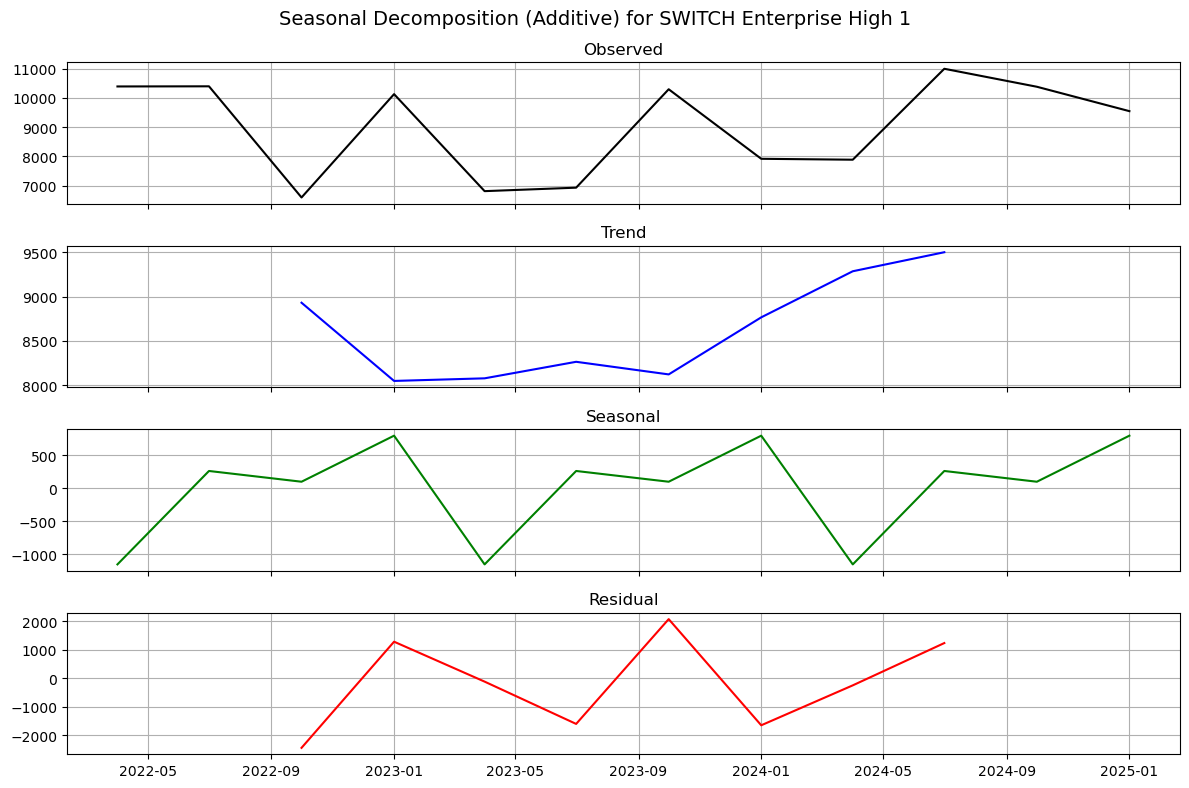

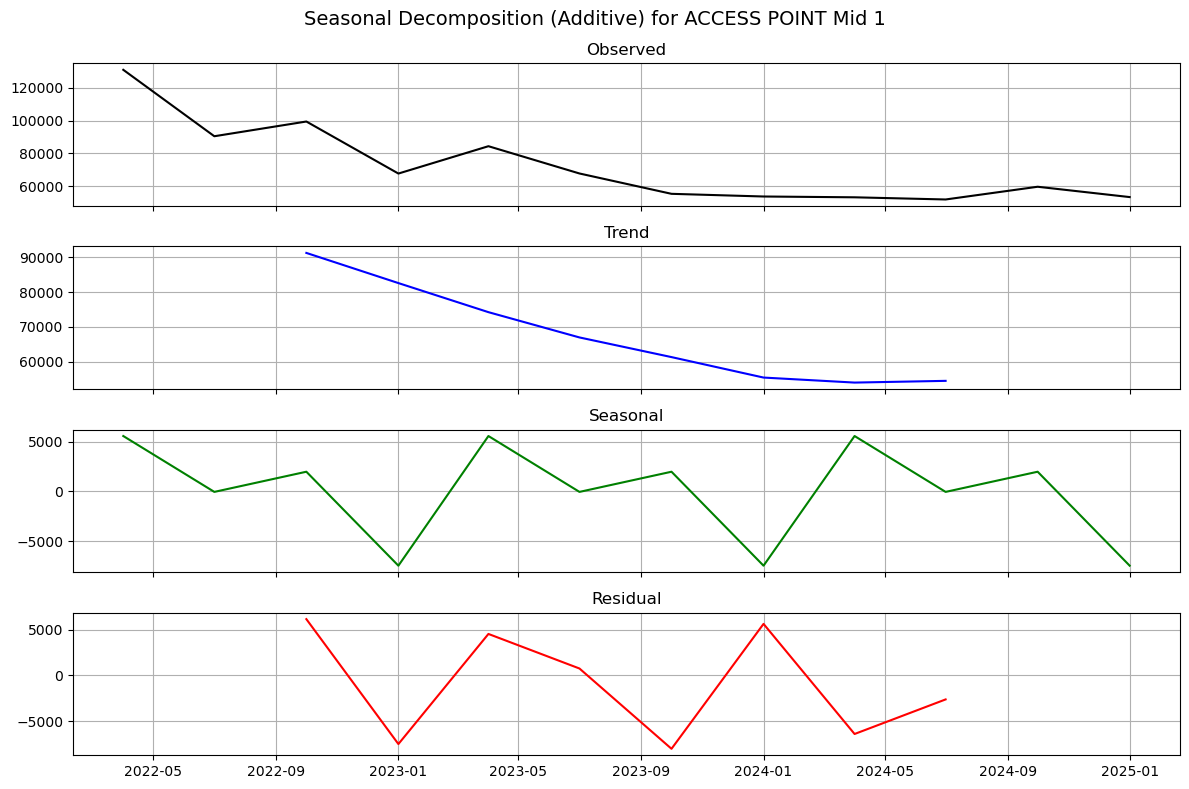

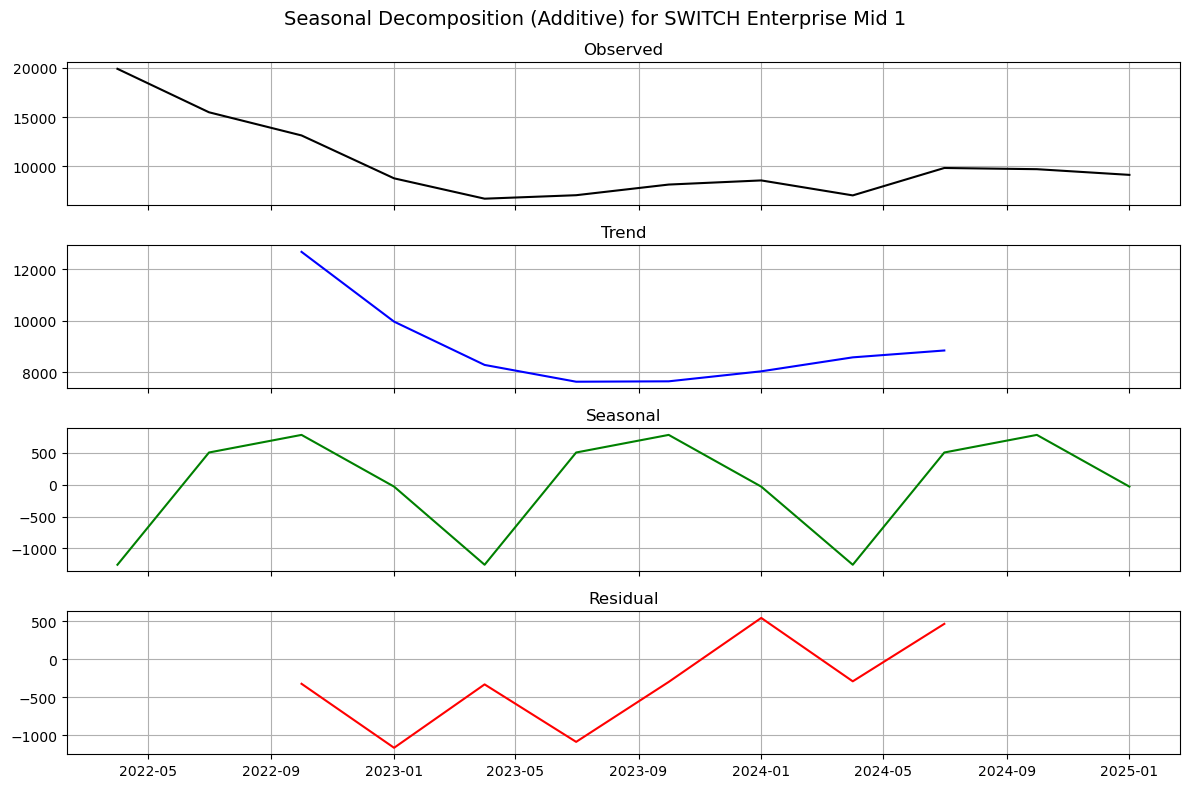

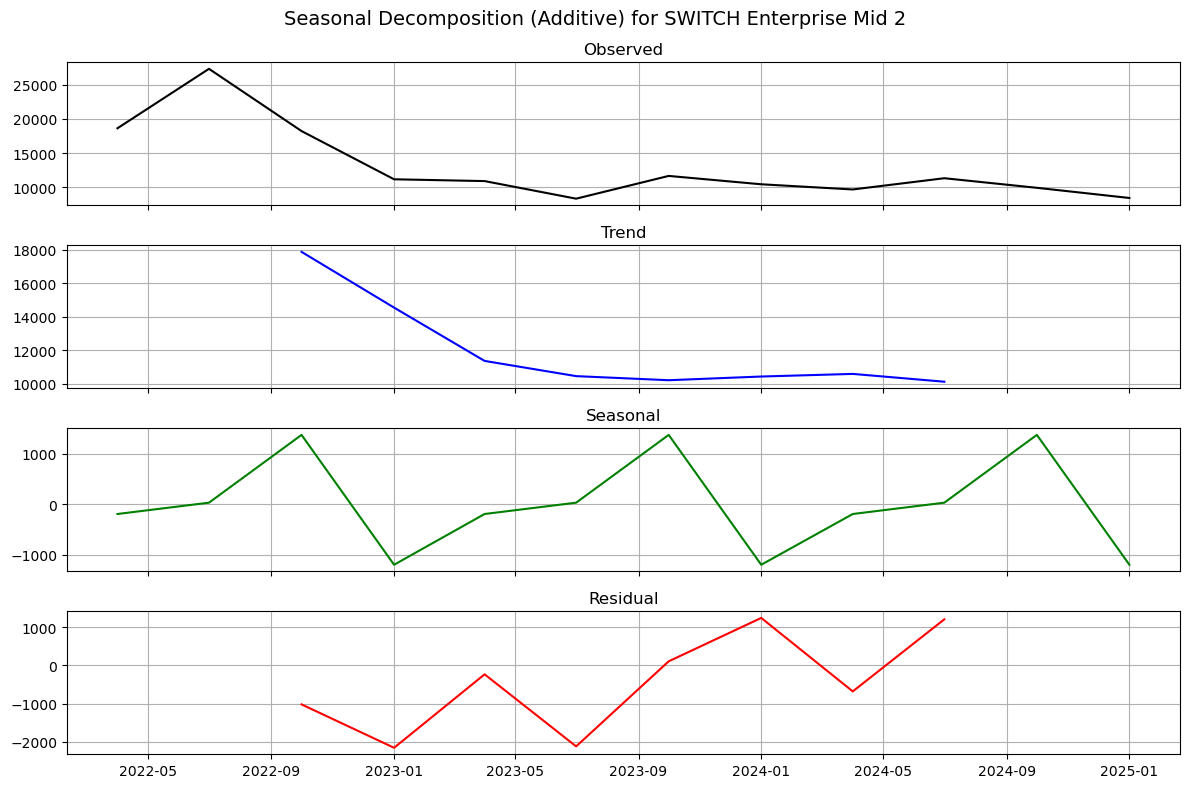

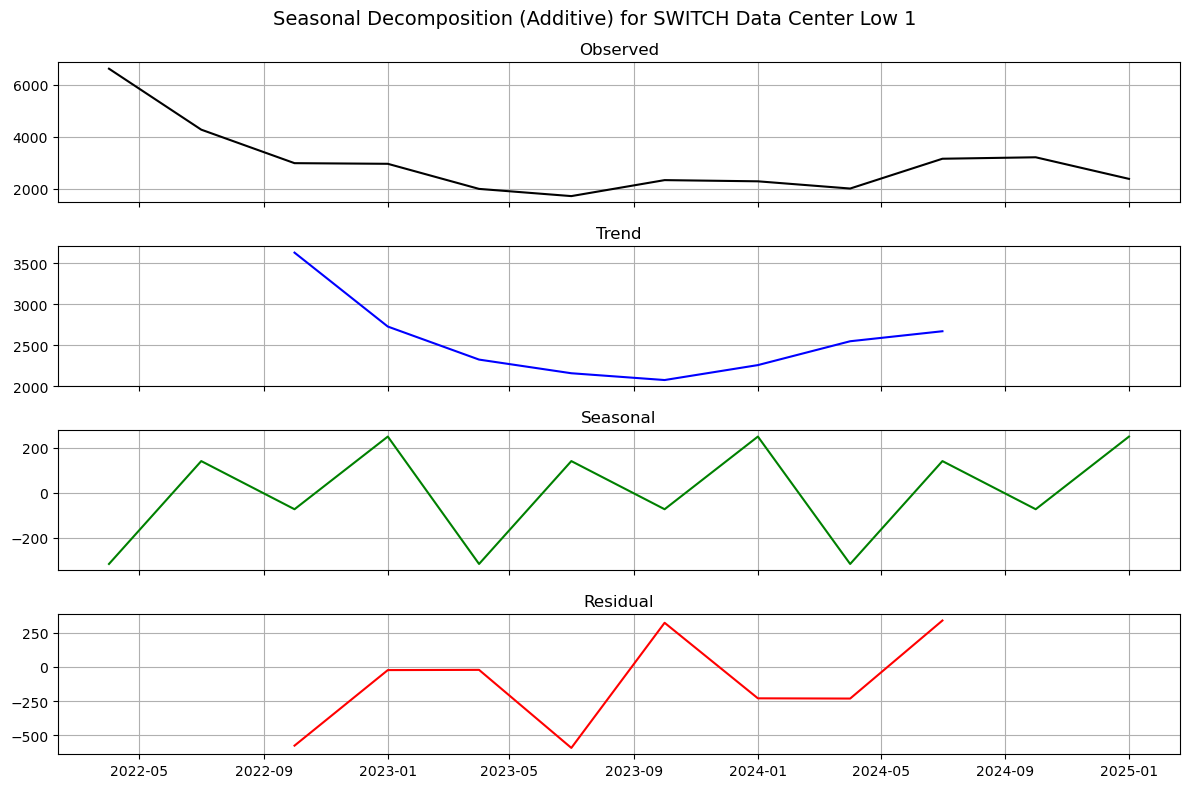

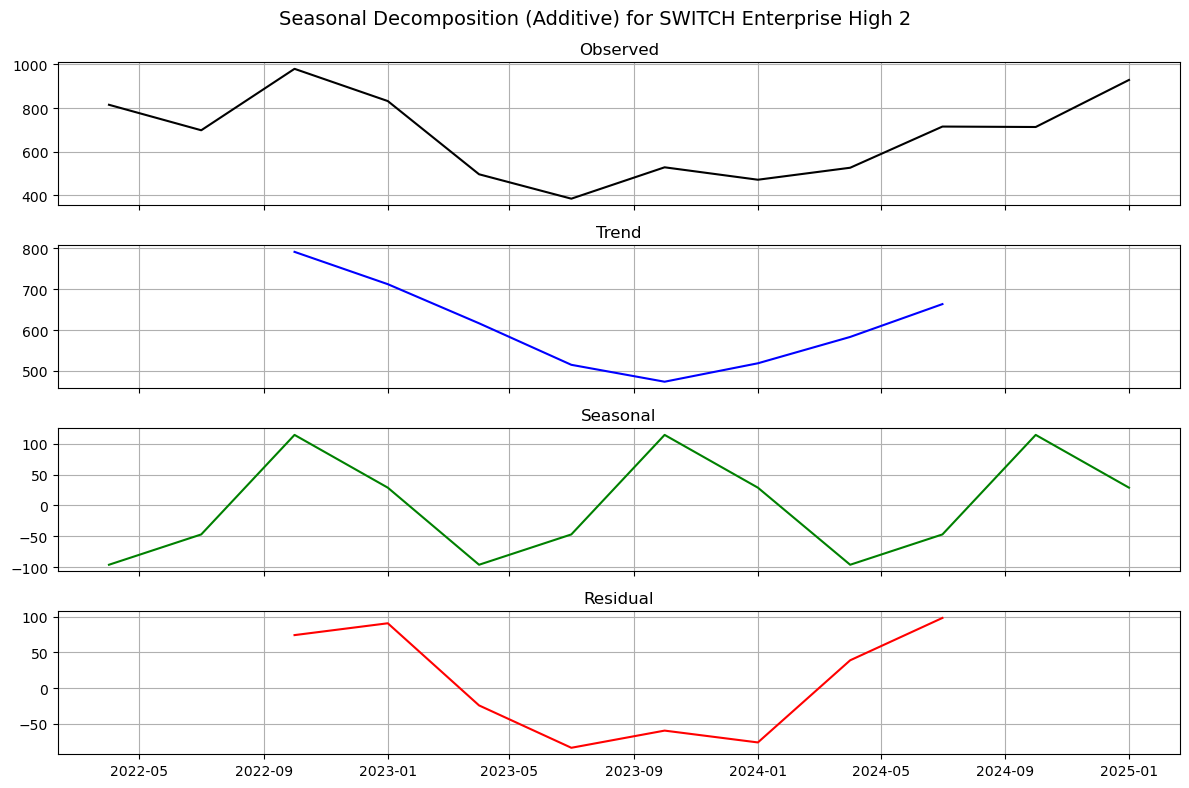

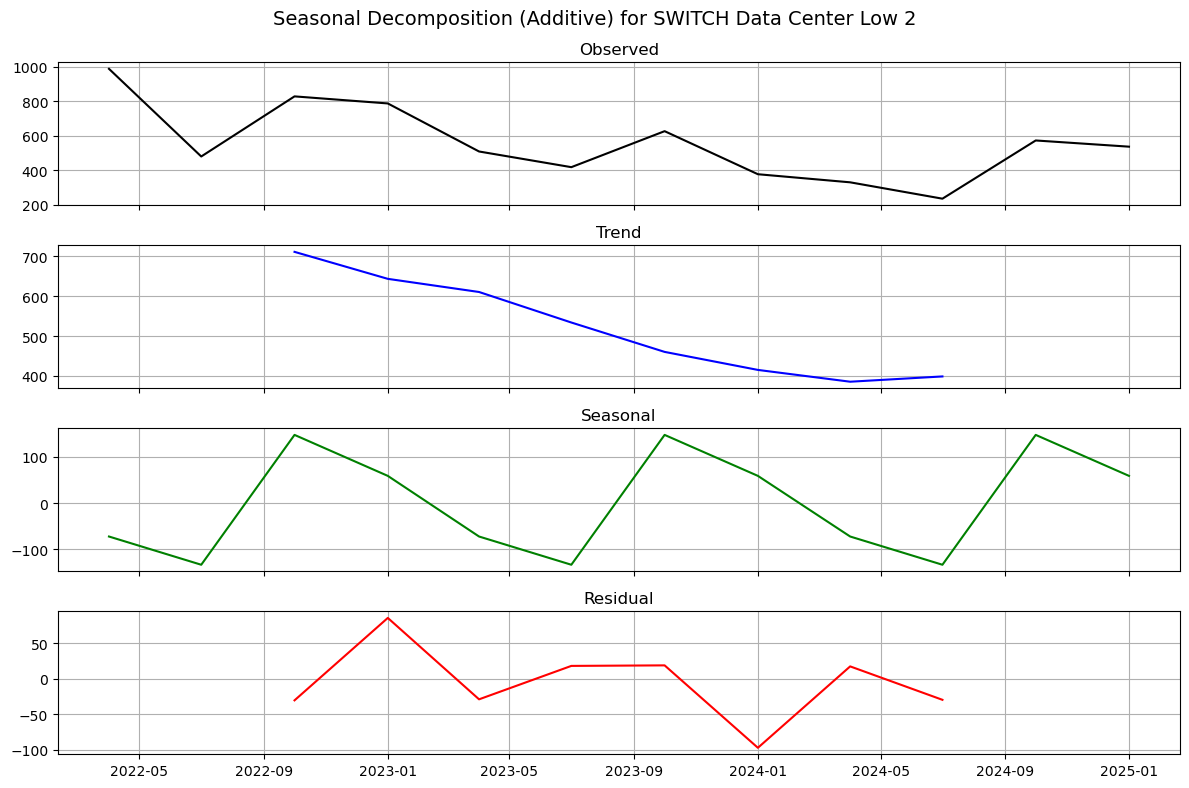

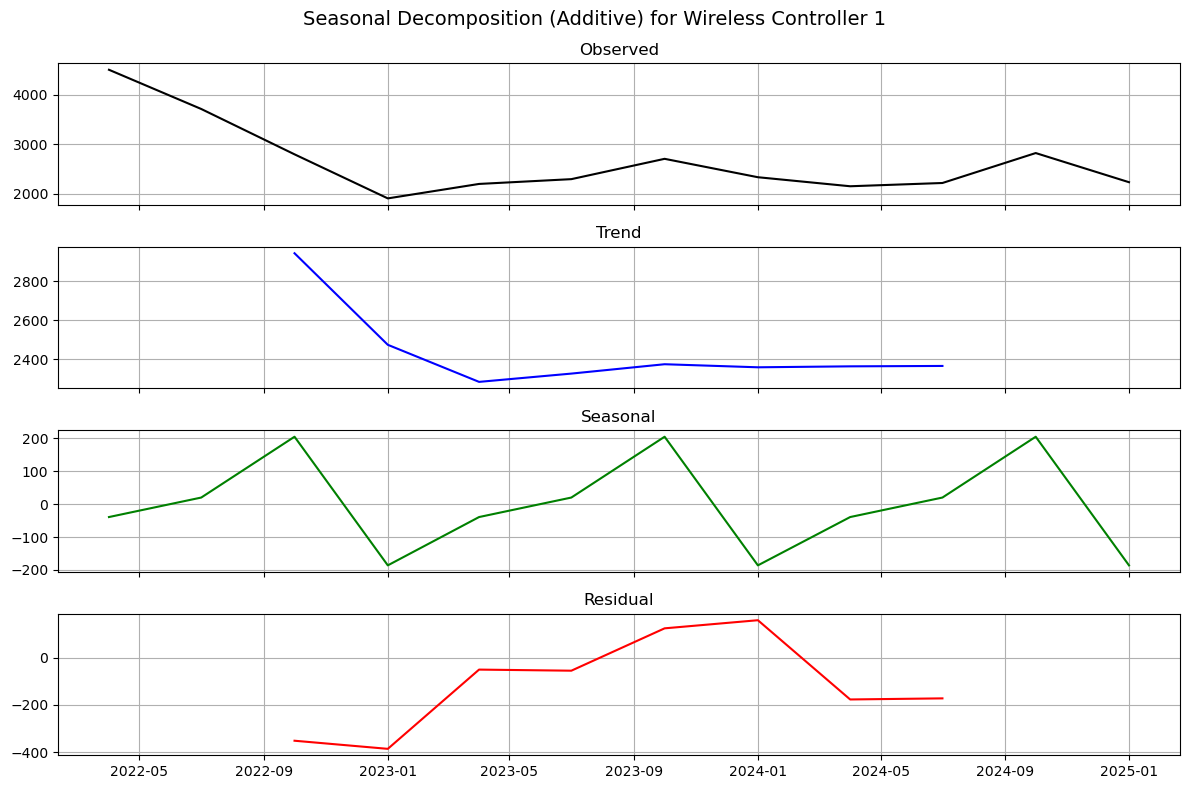

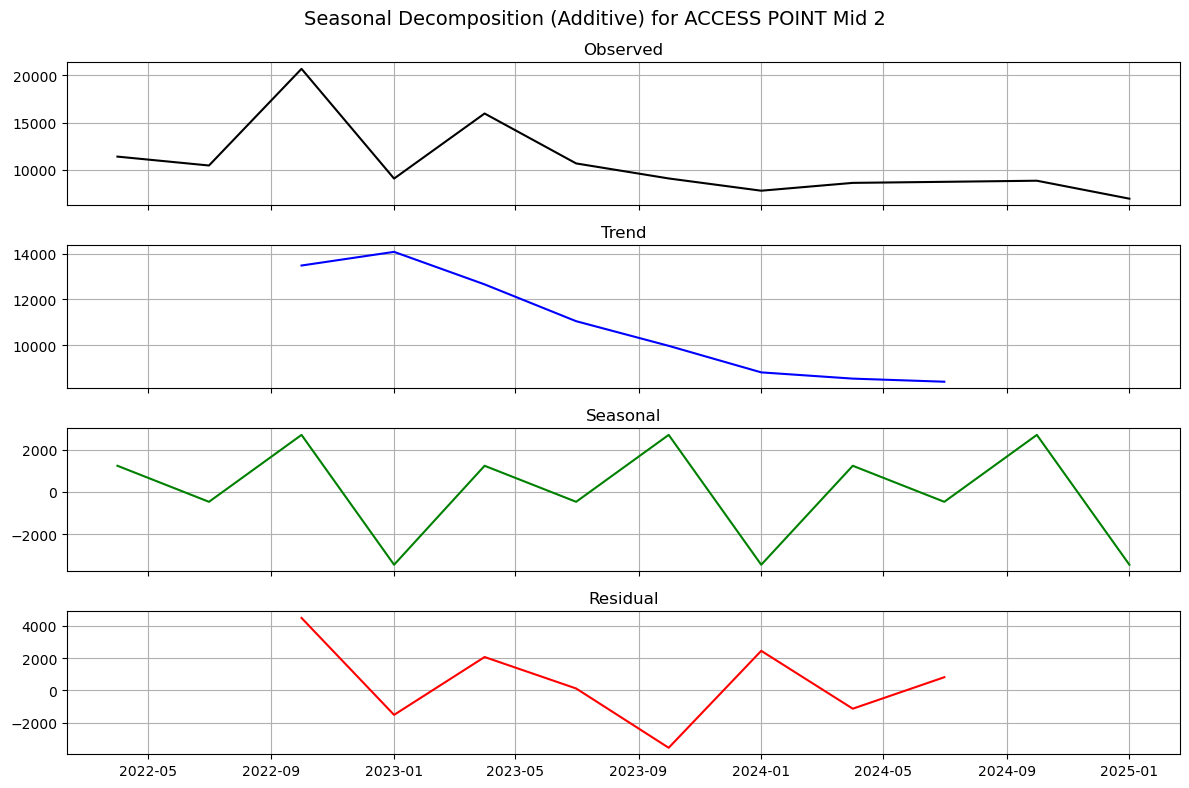

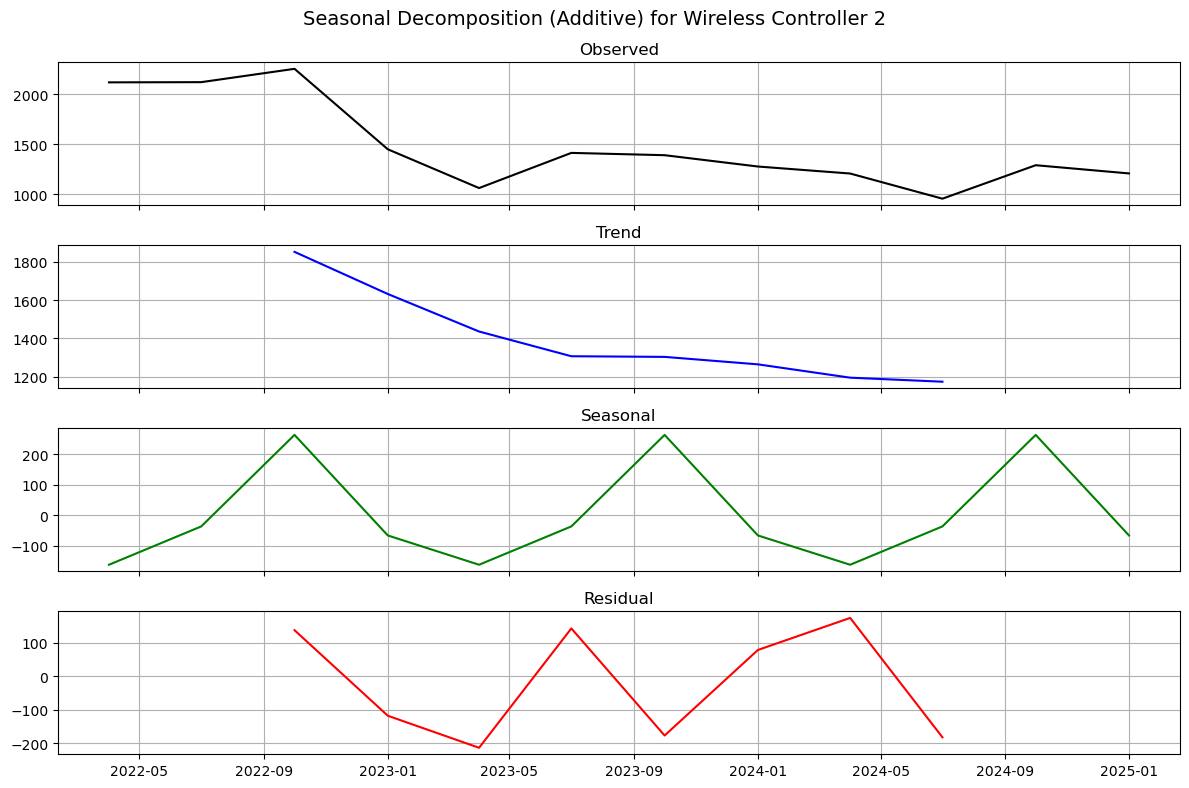

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the dataset
file_path = 'forecasted_values.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
display(df.head())
display(df.info())

# Select 10 products
selected_products = df['Product_Name'].unique()[:10]
df_filtered = df[df['Product_Name'].isin(selected_products)]

# Extract relevant columns (last 12 quarters)
quarters = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1', 'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1', 'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']
df_filtered = df_filtered[['Product_Name'] + quarters]

# Reshape the data into a time series format
df_melted = df_filtered.melt(id_vars=['Product_Name'], var_name='Quarter', value_name='Sales')

# Convert fiscal quarter format into a proper date index
def convert_fy_quarter(fy_quarter):
    year = int(fy_quarter[2:4]) + 2000  # Extract fiscal year
    quarter = int(fy_quarter[-1])  # Extract quarter
    return pd.Period(f'{year}Q{quarter}', freq='Q').to_timestamp()

df_melted['Quarter'] = df_melted['Quarter'].apply(convert_fy_quarter)
df_melted = df_melted.sort_values(by=['Product_Name', 'Quarter'])

# Perform seasonal decomposition for each product
for product in selected_products:
    product_data = df_melted[df_melted['Product_Name'] == product]
    ts = product_data.set_index('Quarter')['Sales']
    
    # Apply Additive decomposition
    additive_decomp = seasonal_decompose(ts, model='additive', period=4)
    
    # Plot results in a single graph with grid
    fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f'Seasonal Decomposition (Additive) for {product}', fontsize=14)
    
    ax[0].plot(additive_decomp.observed, label='Observed', color='black')
    ax[0].set_title('Observed')
    ax[0].grid()
    
    ax[1].plot(additive_decomp.trend, label='Trend', color='blue')
    ax[1].set_title('Trend')
    ax[1].grid()
    
    ax[2].plot(additive_decomp.seasonal, label='Seasonal', color='green')
    ax[2].set_title('Seasonal')
    ax[2].grid()
    
    ax[3].plot(additive_decomp.resid, label='Residual', color='red')
    ax[3].set_title('Residual')
    ax[3].grid()
    
    plt.tight_layout()
    plt.show()

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters fo

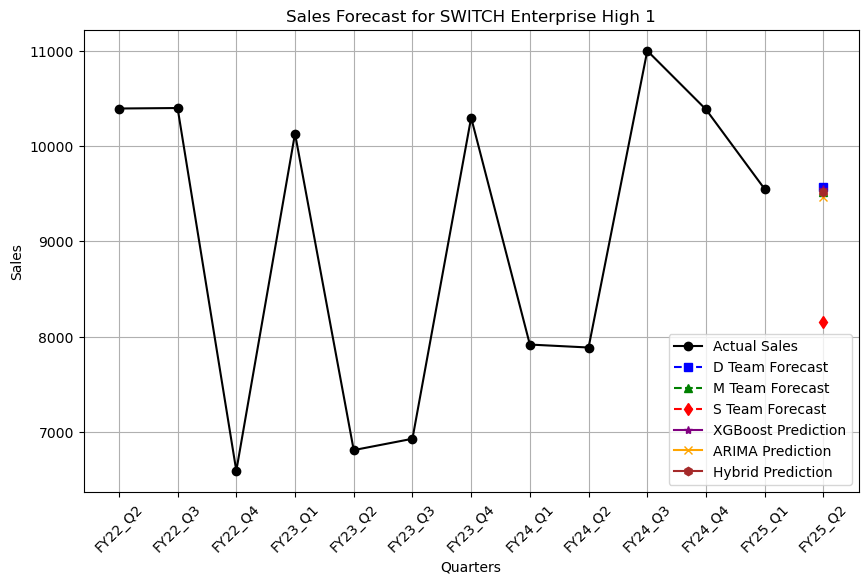

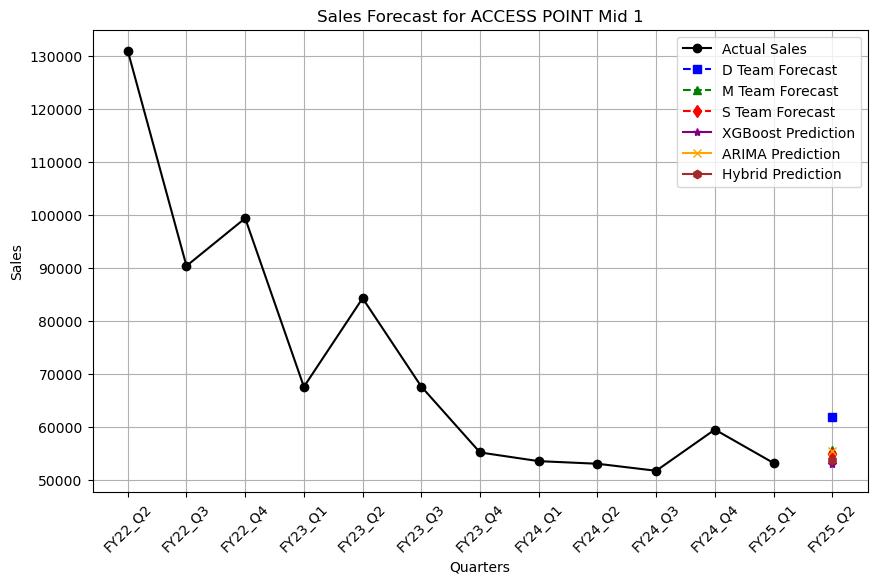

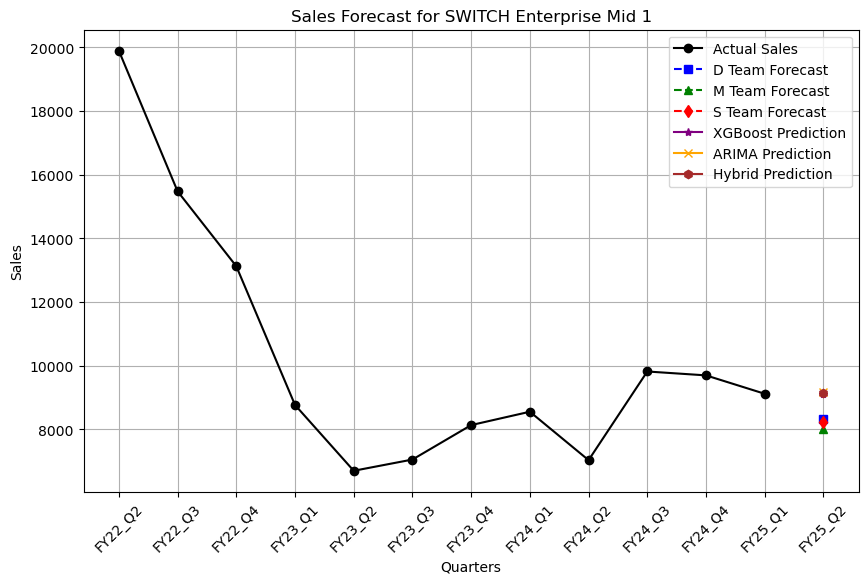

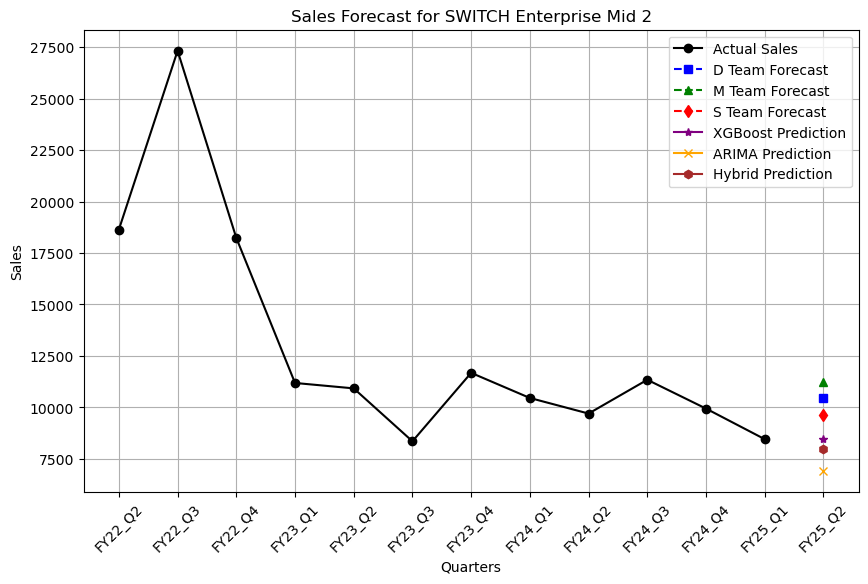

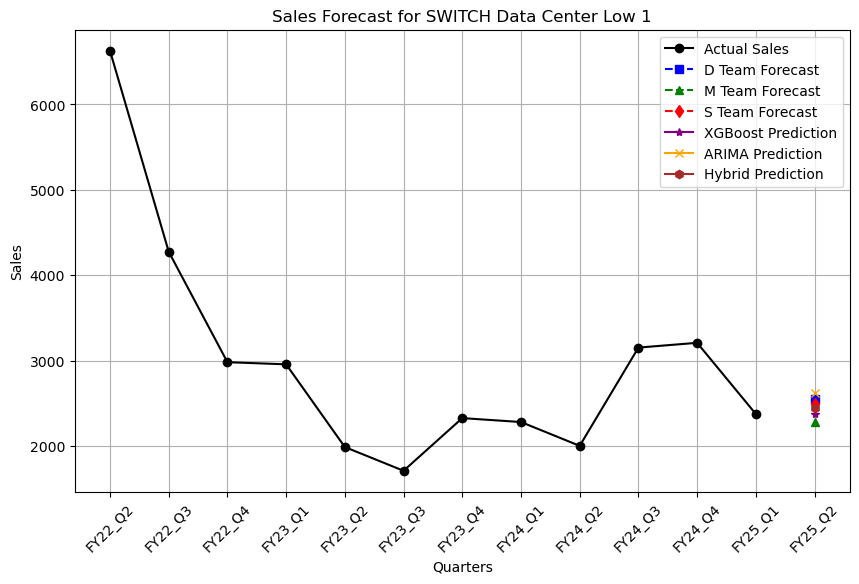

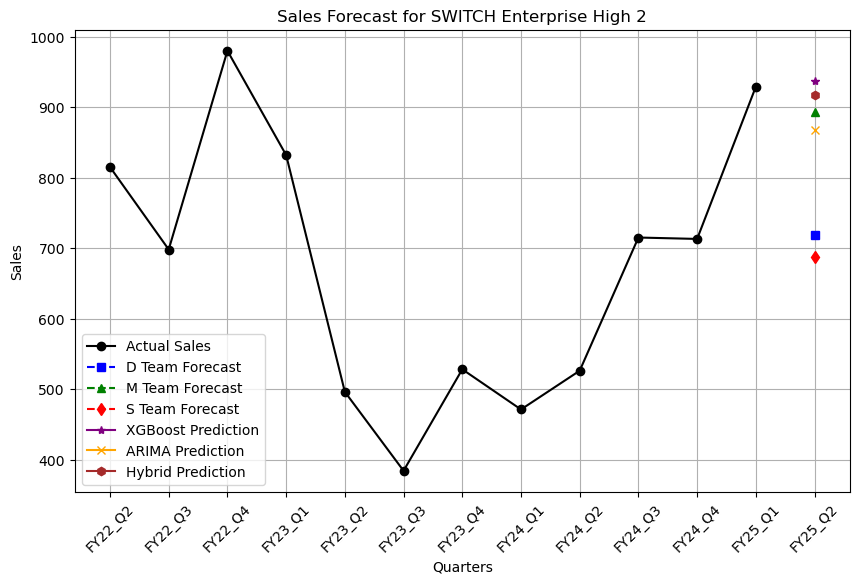

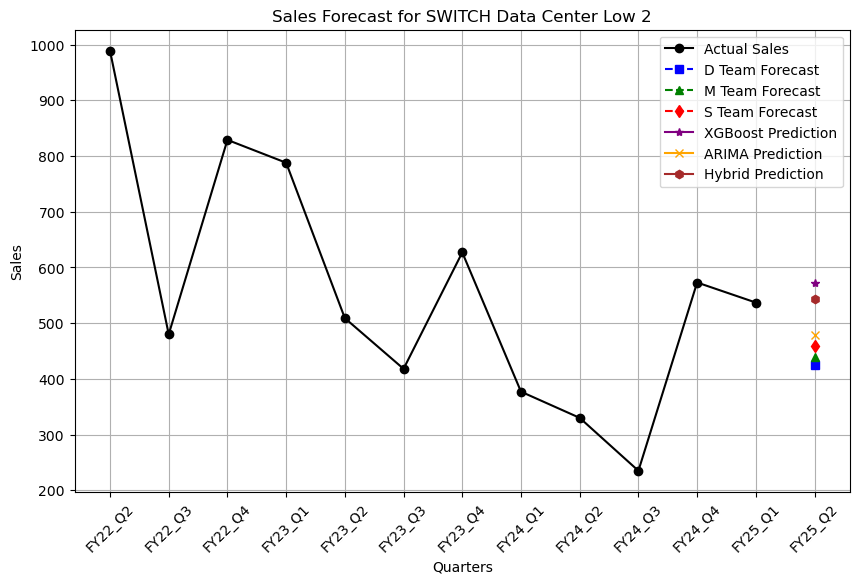

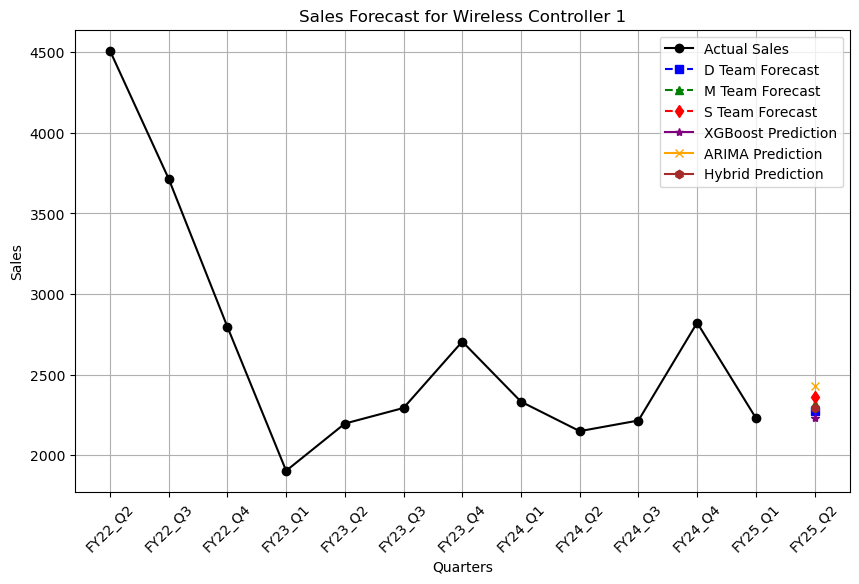

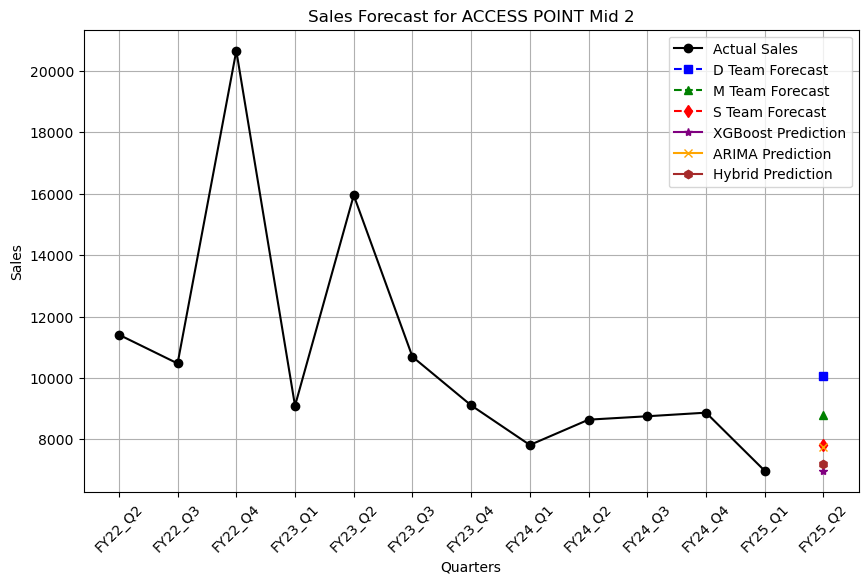

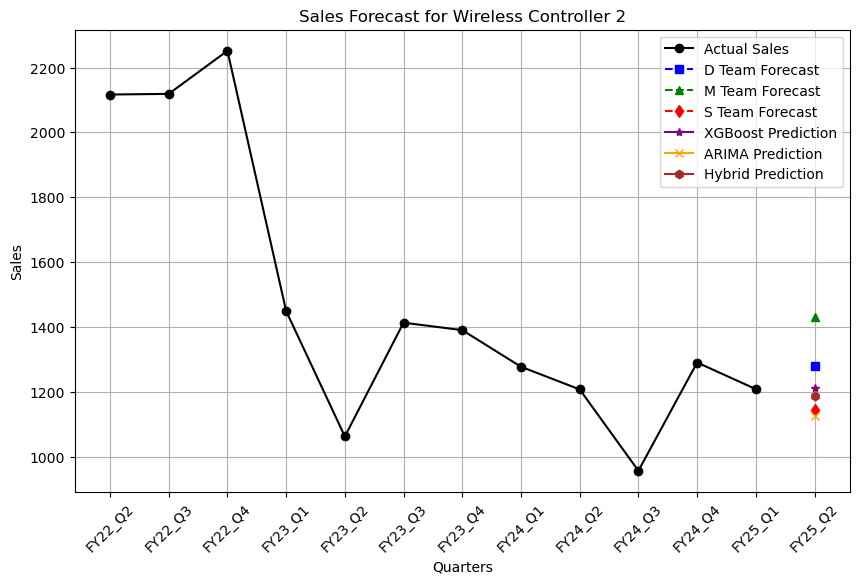

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
df = pd.read_csv("forecasted_values.csv")

# Define columns
actual_columns = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1',
                  'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1',
                  'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']

forecast_columns = {
    "D": ['D_FY24_Q3_Forecasted', 'D_FY24_Q4_Forecasted', 'D_FY25_Q1_Forecasted', 'D_FY2025_Q2_Forecasted'],
    "M": ['M_FY24_Q3_Forecasted', 'M_FY24_Q4_Forecasted', 'M_FY25_Q1_Forecasted', 'M_FY2025_Q2_Forecasted'],
    "S": ['S_FY24_Q3_Forecasted', 'S_FY24_Q4_Forecasted', 'S_FY25_Q1_Forecasted', 'S_FY2025_Q2_Forecasted']
}

# Add trend features
df["Time_Index"] = np.arange(len(df))  # Simple time index
df["Rolling_Mean"] = df[actual_columns].mean(axis=1)  # Moving average

# Features: Past sales + team forecasts (excluding FY25_Q2 forecasted values) + trend features
feature_columns = actual_columns + forecast_columns["D"][:-1] + forecast_columns["M"][:-1] + forecast_columns["S"][:-1] + ["Time_Index", "Rolling_Mean"]

# Drop missing values
df_clean = df.dropna(subset=feature_columns)
X = df_clean[feature_columns]
y = df_clean["FY25_Q1"]

# Train XGBoost with trend features
xgb_model = XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X, y)
df["FY25_Q2_XGBoost"] = xgb_model.predict(df[feature_columns])

# ARIMA Predictions (Capturing Trend)
arima_forecasts = []
for _, row in df.iterrows():
    sales_data = row[actual_columns].values.astype(float)
    try:
        model = ARIMA(sales_data, order=(1,1,1))  # Adjust order if needed
        model_fit = model.fit()
        arima_forecasts.append(model_fit.forecast(steps=1)[0])
    except:
        arima_forecasts.append(np.nan)
df["FY25_Q2_ARIMA"] = arima_forecasts

# Hybrid Model: Averaging XGBoost and ARIMA
weights = [0.7, 0.3]  # Tune weights if needed
df["FY25_Q2_Hybrid"] = (weights[0] * df["FY25_Q2_XGBoost"]) + (weights[1] * df["FY25_Q2_ARIMA"])

# Save predictions to CSV
df[["Product_Name", "FY25_Q2_XGBoost", "FY25_Q2_ARIMA", "FY25_Q2_Hybrid"]].to_csv("FY25_Q2_Predictions_Enhanced.csv", index=False)

# Plot graphs for each product
for product in df["Product_Name"].unique():
    product_data = df[df["Product_Name"] == product].iloc[0]
    
    actual_sales = product_data[actual_columns].values.flatten()
    d_forecast, m_forecast, s_forecast = product_data[forecast_columns["D"][-1]], product_data[forecast_columns["M"][-1]], product_data[forecast_columns["S"][-1]]
    xgb_prediction = product_data["FY25_Q2_XGBoost"]
    arima_prediction = product_data["FY25_Q2_ARIMA"]
    hybrid_prediction = product_data["FY25_Q2_Hybrid"]
    
    quarters = actual_columns + ["FY25_Q2"]
    all_sales = list(actual_sales) + [None]
    d_values, m_values, s_values = [None] * len(actual_sales) + [d_forecast], [None] * len(actual_sales) + [m_forecast], [None] * len(actual_sales) + [s_forecast]
    xgb_values, arima_values, hybrid_values = [None] * len(actual_sales) + [xgb_prediction], [None] * len(actual_sales) + [arima_prediction], [None] * len(actual_sales) + [hybrid_prediction]
    
    plt.figure(figsize=(10, 6))
    plt.plot(quarters, all_sales, label="Actual Sales", marker="o", color="black")
    plt.plot(quarters, d_values, label="D Team Forecast", linestyle="--", marker="s", color="blue")
    plt.plot(quarters, m_values, label="M Team Forecast", linestyle="--", marker="^", color="green")
    plt.plot(quarters, s_values, label="S Team Forecast", linestyle="--", marker="d", color="red")
    plt.plot(quarters, xgb_values, label="XGBoost Prediction", linestyle="-", marker="*", color="purple")
    plt.plot(quarters, arima_values, label="ARIMA Prediction", linestyle="-", marker="x", color="orange")
    plt.plot(quarters, hybrid_values, label="Hybrid Prediction", linestyle="-", marker="h", color="brown")
    
    plt.title(f"Sales Forecast for {product}")
    plt.xlabel("Quarters")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.44189D-01    |proj g|=  2.31911D-02

At iterate    5    f=  7.42728D-01    |proj g|=  2.81293D-05

At iterate   10    f=  7.42727D-01    |proj g|=  4.73896D-04

At iterate   15    f=  7.42682D-01    |proj g|=  2.85176D-03

At iterate   20    f=  7.42582D-01    |proj g|=  4.19925D-03

At iterate   25    f=  7.42455D-01    |proj g|=  2.85071D-03

At iterate   30    f=  7.41939D-01    |proj g|=  9.83893D-04

At iterate   35    f=  7.39978D-01    |proj g|=  2.00327D-02

At iterate   40    f=  7.34660D-01    |proj g|=  1.32181D-01

At iterate   45    f=  6.60810D-01    |proj g|=  4.43009D+00

At iterate   50    f=  6.46190D-01    |proj g|=  1.09028D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: U

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.81702D-01    |proj g|=  2.41408D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5      3      6      1     0     0   5.387D-06   8.805D-01
  F =  0.88045616747046374     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.0

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters ex


At iterate   10    f=  5.42052D-01    |proj g|=  6.92713D-04

At iterate   15    f=  5.41724D-01    |proj g|=  2.81037D-03

At iterate   20    f=  5.32390D-01    |proj g|=  1.90231D-02

At iterate   25    f=  5.18848D-01    |proj g|=  2.90606D-02

At iterate   30    f=  4.93312D-01    |proj g|=  2.97768D-01
  ys=-7.290E-01  -gs= 6.040E-02 BFGS update SKIPPED

At iterate   35    f=  3.21677D-01    |proj g|=  1.89594D-01

At iterate   40    f=  3.06496D-01    |proj g|=  4.61088D-01
  ys=-1.628E-03  -gs= 5.209E-03 BFGS update SKIPPED

At iterate   45    f=  3.01726D-01    |proj g|=  2.09161D+00

At iterate   50    f=  2.93507D-01    |proj g|=  7.04558D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function v

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters ex


At iterate   30    f=  4.51991D-01    |proj g|=  8.47651D-02

At iterate   35    f=  3.15684D-01    |proj g|=  8.75807D-01
  ys=-7.625E-02  -gs= 8.228E-02 BFGS update SKIPPED

At iterate   40    f=  9.58964D-02    |proj g|=  3.46990D+01

At iterate   45    f= -1.22154D-02    |proj g|=  4.89959D+01

At iterate   50    f= -6.22272D-02    |proj g|=  1.06172D+02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50    129      1     1     0   1.062D+02  -6.223D-02
  F =  -6.2227211071021686E-002

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
RUNNING THE L-BFGS-B CODE

           * * *

Machine precisio

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.
/home

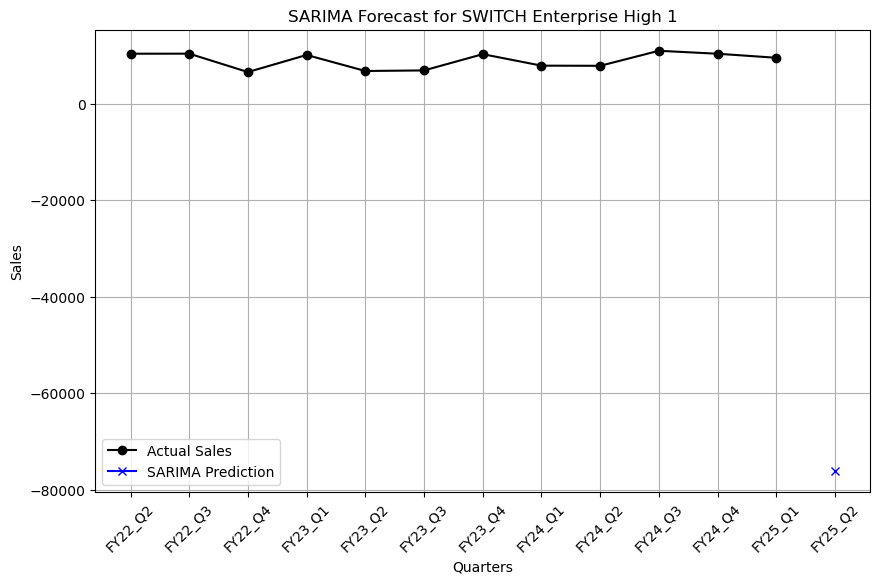

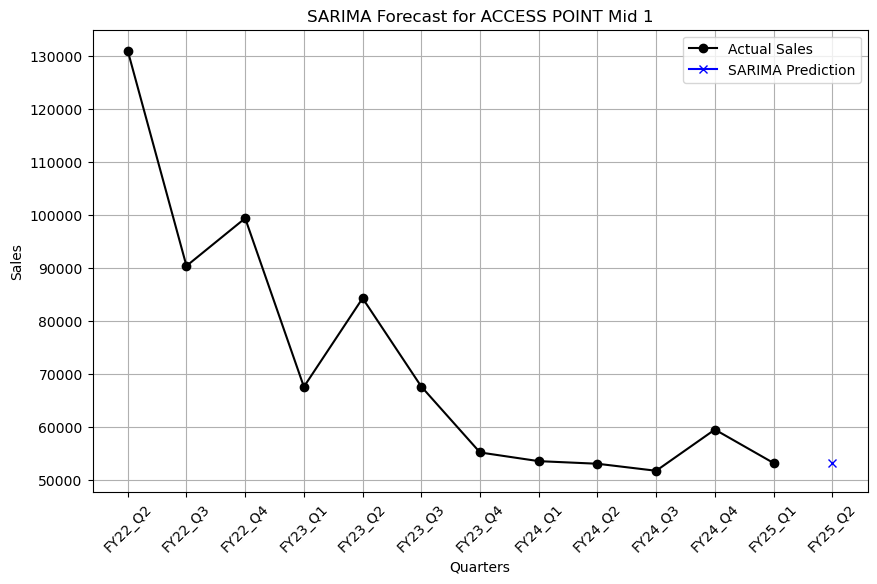

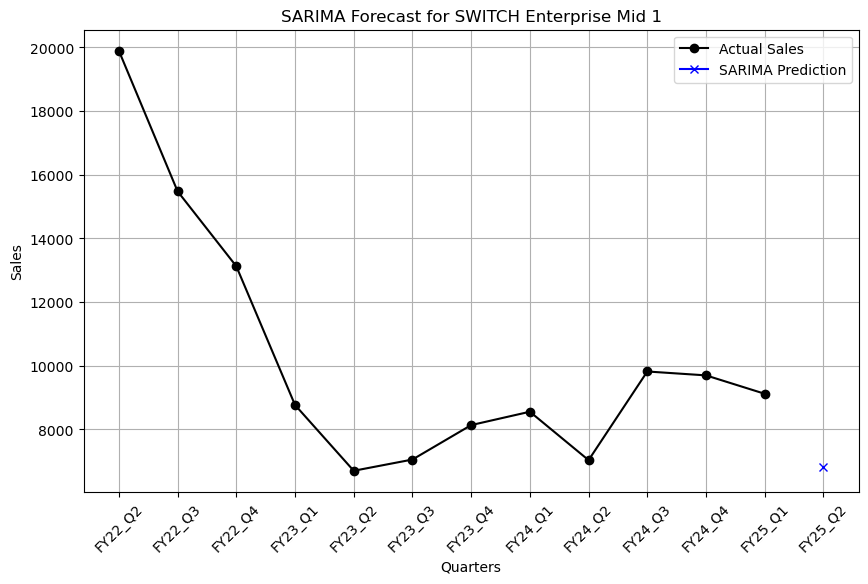

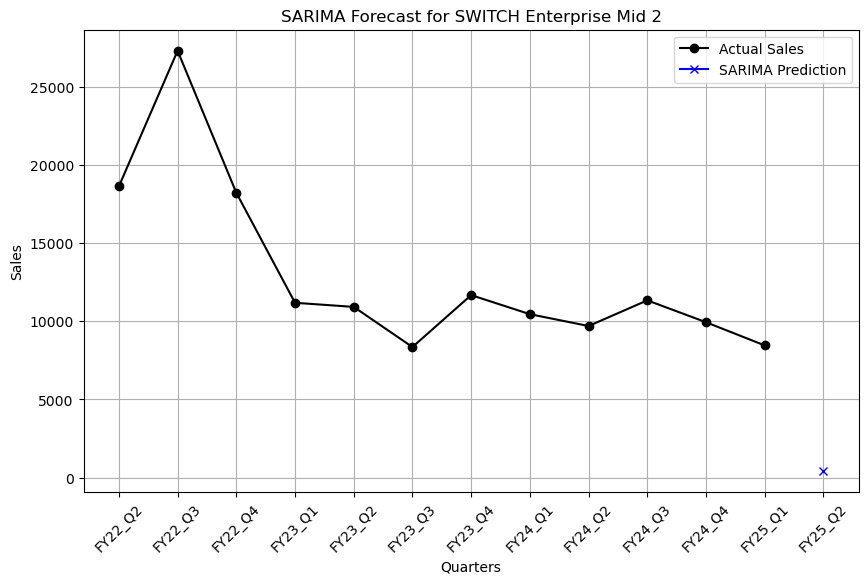

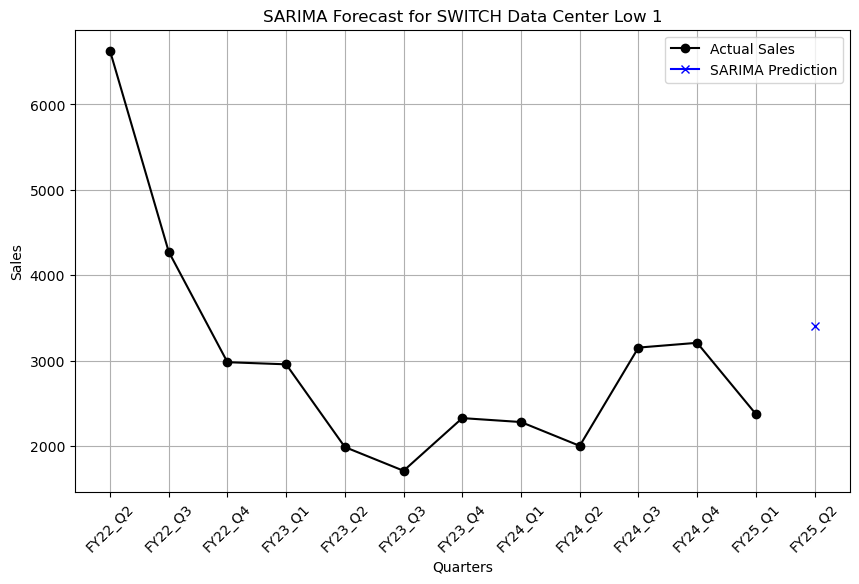

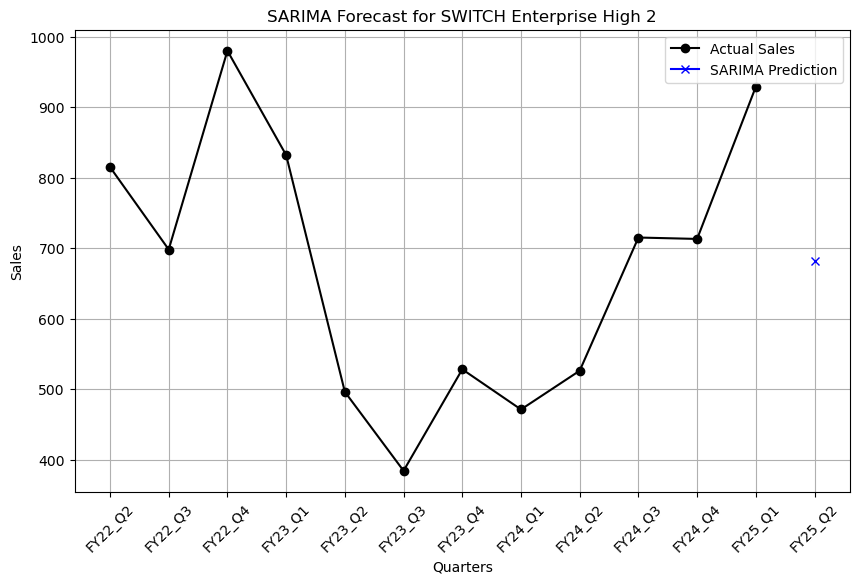

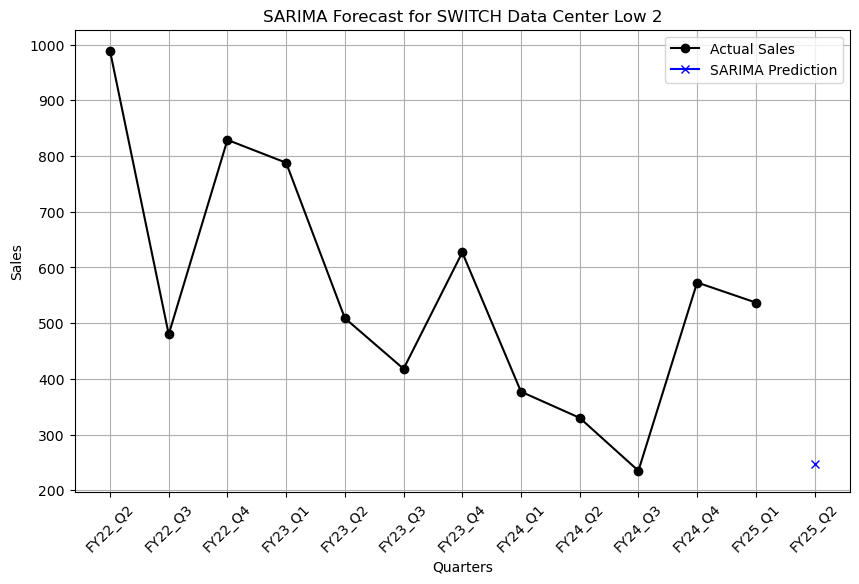

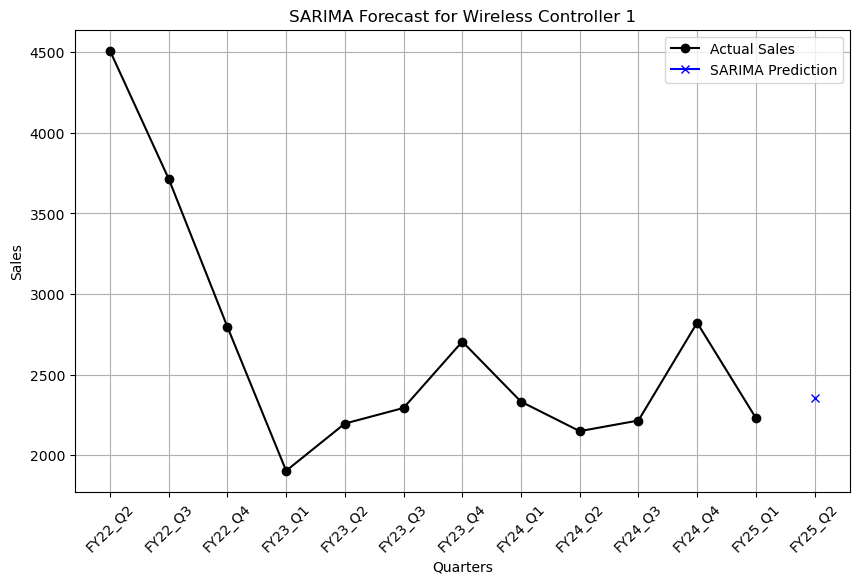

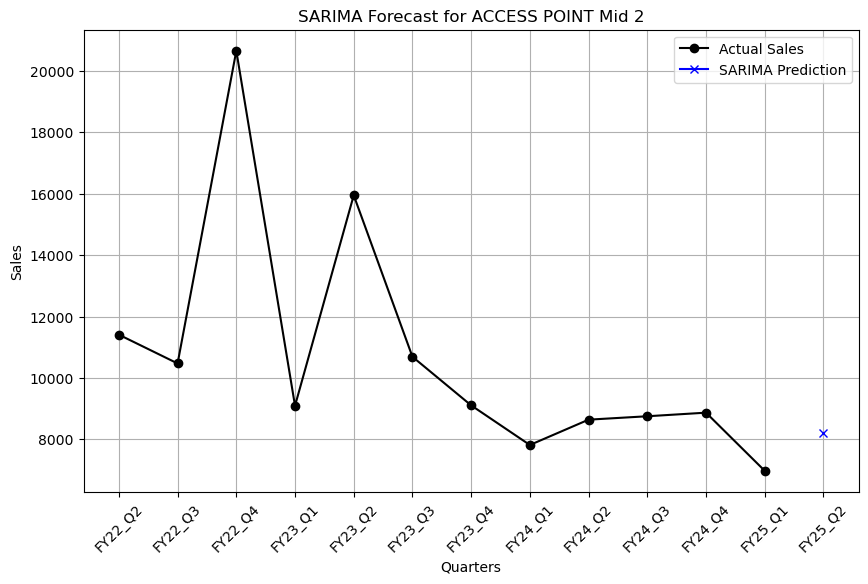

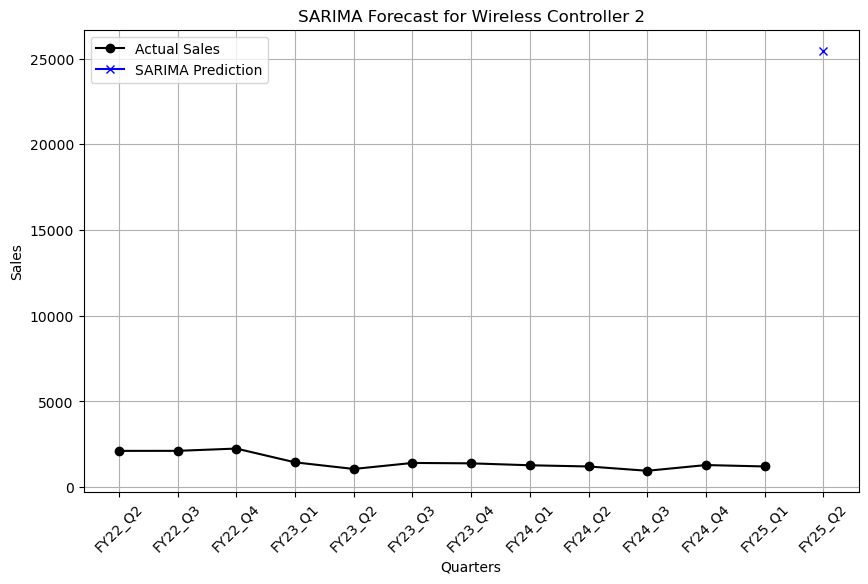

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
file_path = "forecasted_values.csv"
df = pd.read_csv(file_path)

# Define columns
actual_columns = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1',
                  'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1',
                  'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']

# Initialize predictions list
sarima_forecasts = []

# SARIMA Model for each product
for _, row in df.iterrows():
    sales_data = row[actual_columns].values.astype(float)
    try:
        model = SARIMAX(sales_data, order=(1,1,1), seasonal_order=(1,1,1,4), enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit()
        sarima_forecasts.append(model_fit.forecast(steps=1)[0])
    except:
        sarima_forecasts.append(np.nan)

# Store SARIMA Predictions
df["FY25_Q2_SARIMA"] = sarima_forecasts

# Save predictions to CSV
df[["Product_Name", "FY25_Q2_SARIMA"]].to_csv("FY25_Q2_SARIMA_Predictions.csv", index=False)

# Plot SARIMA Predictions for Each Product
for product in df["Product_Name"].unique():
    product_data = df[df["Product_Name"] == product].iloc[0]
    actual_sales = product_data[actual_columns].values.flatten()
    sarima_prediction = product_data["FY25_Q2_SARIMA"]
    
    quarters = actual_columns + ["FY25_Q2"]
    all_sales = list(actual_sales) + [None]
    sarima_values = [None] * len(actual_sales) + [sarima_prediction]
    
    plt.figure(figsize=(10, 6))
    plt.plot(quarters, all_sales, label="Actual Sales", marker="o", color="black")
    plt.plot(quarters, sarima_values, label="SARIMA Prediction", linestyle="-", marker="x", color="blue")
    
    plt.title(f"SARIMA Forecast for {product}")
    plt.xlabel("Quarters")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: U

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.44189D-01    |proj g|=  2.31911D-02

At iterate    5    f=  7.42728D-01    |proj g|=  2.81293D-05

At iterate   10    f=  7.42727D-01    |proj g|=  4.73896D-04

At iterate   15    f=  7.42682D-01    |proj g|=  2.85176D-03

At iterate   20    f=  7.42582D-01    |proj g|=  4.19925D-03

At iterate   25    f=  7.42455D-01    |proj g|=  2.85071D-03

At iterate   30    f=  7.41939D-01    |proj g|=  9.83893D-04

At iterate   35    f=  7.39978D-01    |proj g|=  2.00327D-02

At iterate   40    f=  7.34660D-01    |proj g|=  1.32181D-01

At iterate   45    f=  6.60810D-01    |proj g|=  4.43009D+00

At iterate   50    f=  6.46190D-01    |proj g|=  1.09028D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters ex


At iterate    5    f=  7.04130D-01    |proj g|=  2.03989D-02

At iterate   10    f=  6.37681D-01    |proj g|=  1.56308D-01

At iterate   15    f=  5.88614D-01    |proj g|=  1.07458D-01

At iterate   20    f=  5.79814D-01    |proj g|=  5.89657D-02

At iterate   25    f=  5.74409D-01    |proj g|=  1.88331D-01

At iterate   30    f=  5.70846D-01    |proj g|=  1.15954D-02

At iterate   35    f=  5.68845D-01    |proj g|=  8.25026D-02

At iterate   40    f=  5.68635D-01    |proj g|=  2.65376D-02

At iterate   45    f=  5.68577D-01    |proj g|=  2.74278D-03

At iterate   50    f=  5.68565D-01    |proj g|=  9.12076D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters ex


At iterate   15    f=  4.98725D-01    |proj g|=  6.36015D-03

At iterate   20    f=  4.98641D-01    |proj g|=  1.18861D-02

At iterate   25    f=  4.98300D-01    |proj g|=  8.48310D-03

At iterate   30    f=  4.97665D-01    |proj g|=  1.83625D-02

At iterate   35    f=  4.97493D-01    |proj g|=  9.87993D-03

At iterate   40    f=  4.96947D-01    |proj g|=  6.45244D-03

At iterate   45    f=  4.95834D-01    |proj g|=  1.82392D-02

At iterate   50    f=  4.93649D-01    |proj g|=  5.31011D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50     82      1     0     0   5.310D-02   4.936D-01
  F =  0.493648605892

/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.
/home


At iterate   50    f=  3.37521D-01    |proj g|=  1.15575D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50    106      2     1     0   1.156D-01   3.375D-01
  F =  0.33752063315153097     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


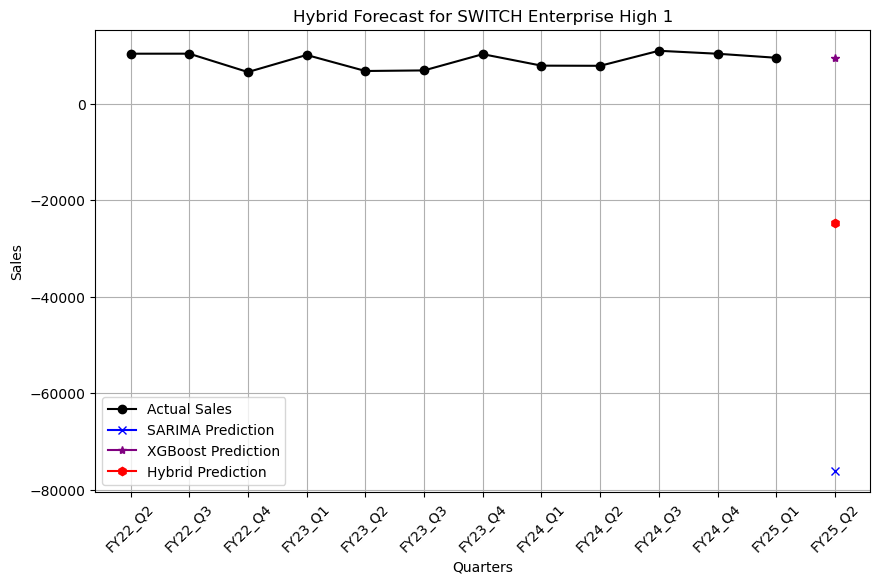

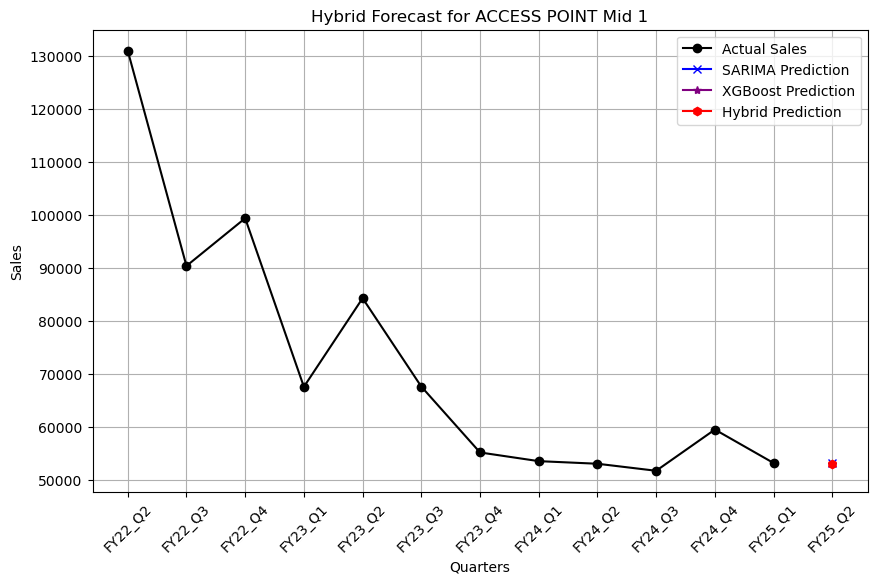

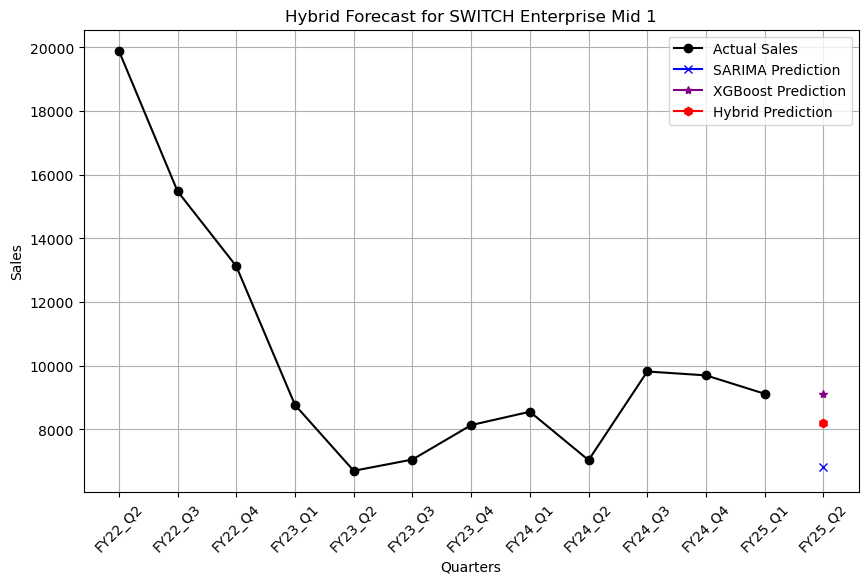

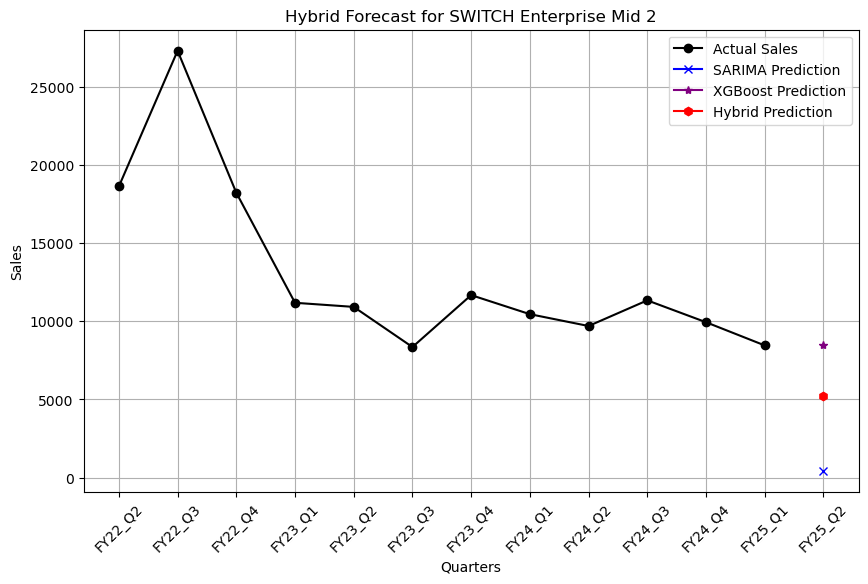

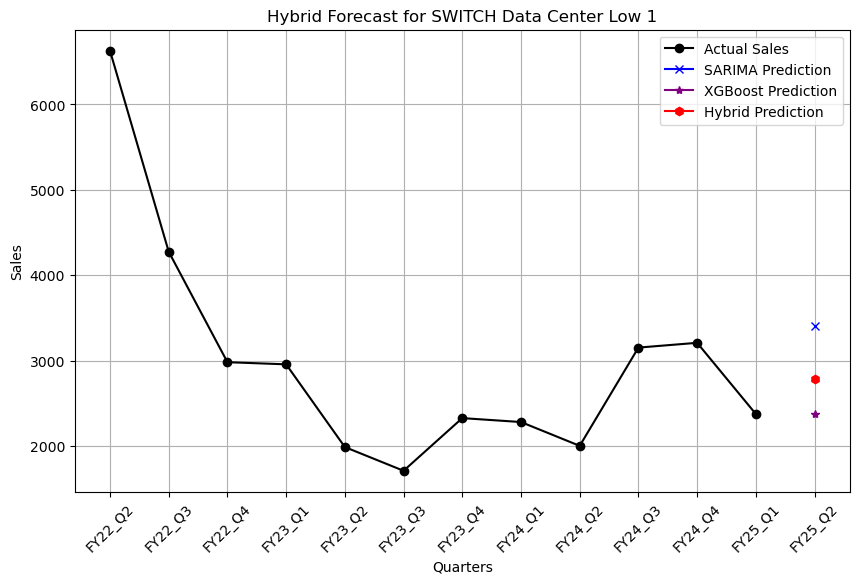

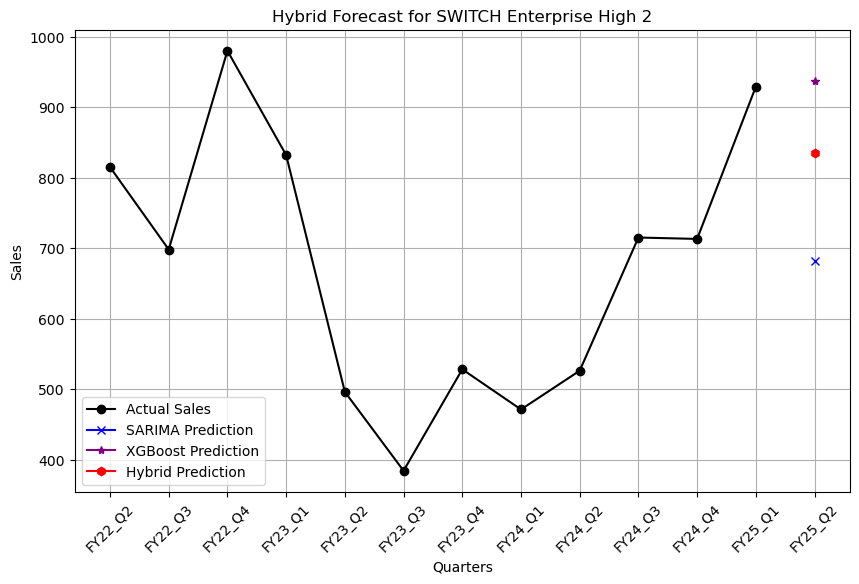

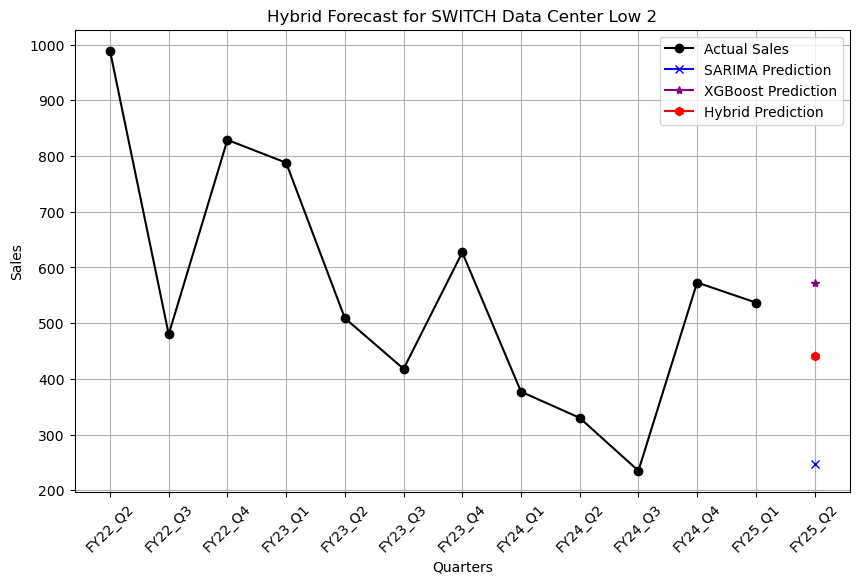

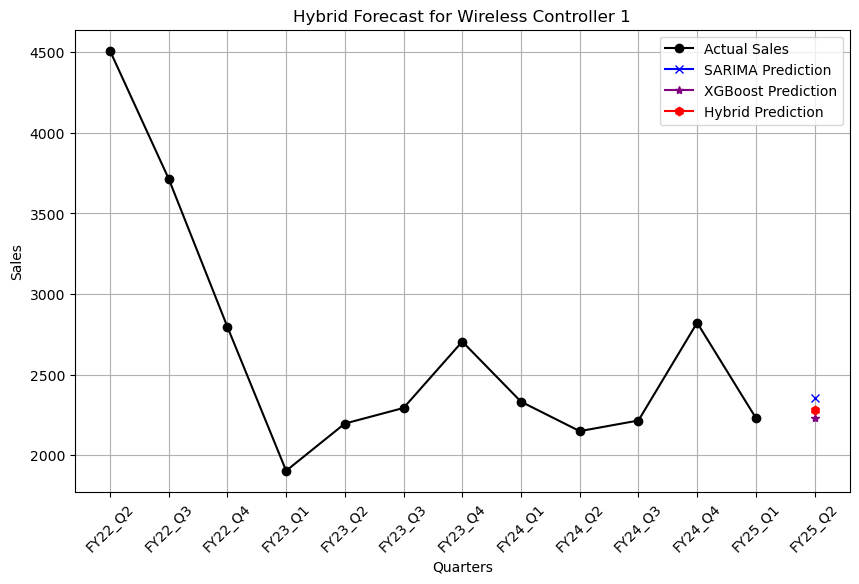

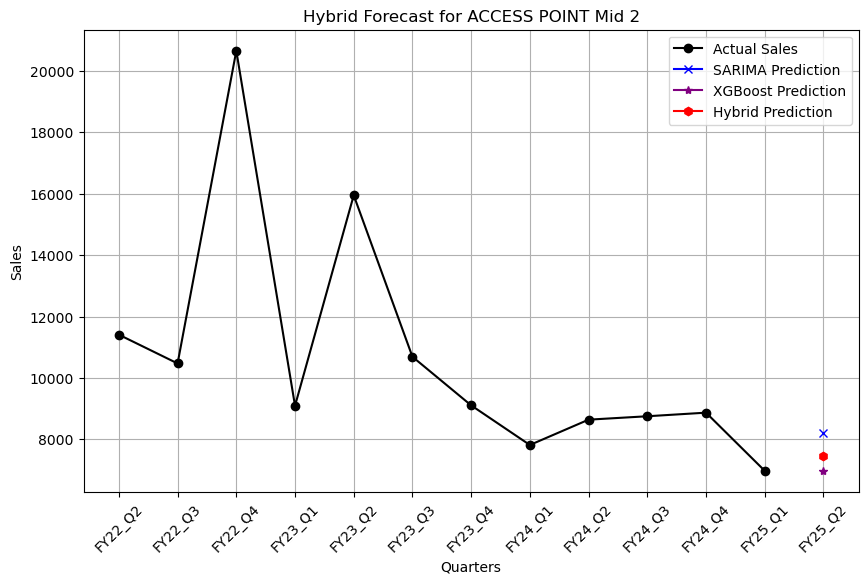

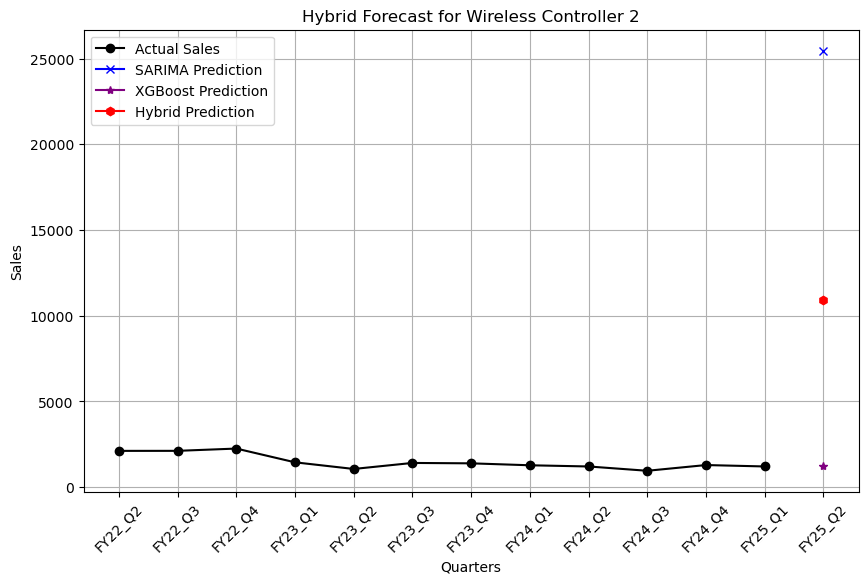

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

# Load dataset
file_path = "forecasted_values.csv"
df = pd.read_csv(file_path)

# Define columns
actual_columns = ['FY22_Q2', 'FY22_Q3', 'FY22_Q4', 'FY23_Q1',
                  'FY23_Q2', 'FY23_Q3', 'FY23_Q4', 'FY24_Q1',
                  'FY24_Q2', 'FY24_Q3', 'FY24_Q4', 'FY25_Q1']

# Initialize predictions list
sarima_forecasts = []

# SARIMA Model for each product
for _, row in df.iterrows():
    sales_data = row[actual_columns].values.astype(float)
    try:
        model = SARIMAX(sales_data, order=(1,1,1), seasonal_order=(1,1,1,4), enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit()
        sarima_forecasts.append(model_fit.forecast(steps=1)[0])
    except:
        sarima_forecasts.append(np.nan)

# Store SARIMA Predictions
df["FY25_Q2_SARIMA"] = sarima_forecasts

# Prepare XGBoost Features
df["Time_Index"] = np.arange(len(df))  # Simple time index
df["Rolling_Mean"] = df[actual_columns].mean(axis=1)  # Moving average
feature_columns = actual_columns + ["Time_Index", "Rolling_Mean"]

# Train XGBoost Model
df_clean = df.dropna(subset=feature_columns)
X = df_clean[feature_columns]
y = df_clean["FY25_Q1"]
xgb_model = XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X, y)
df["FY25_Q2_XGBoost"] = xgb_model.predict(df[feature_columns])

# Hybrid Model: Combining SARIMA & XGBoost
weights = [0.6, 0.4]  # Adjust weights if needed
df["FY25_Q2_Hybrid"] = (weights[0] * df["FY25_Q2_XGBoost"]) + (weights[1] * df["FY25_Q2_SARIMA"])

# Save predictions to CSV
df[["Product_Name", "FY25_Q2_SARIMA", "FY25_Q2_XGBoost", "FY25_Q2_Hybrid"]].to_csv("FY25_Q2_Hybrid_Predictions.csv", index=False)

# Plot Hybrid Model Predictions for Each Product
for product in df["Product_Name"].unique():
    product_data = df[df["Product_Name"] == product].iloc[0]
    actual_sales = product_data[actual_columns].values.flatten()
    sarima_prediction = product_data["FY25_Q2_SARIMA"]
    xgb_prediction = product_data["FY25_Q2_XGBoost"]
    hybrid_prediction = product_data["FY25_Q2_Hybrid"]
    
    quarters = actual_columns + ["FY25_Q2"]
    all_sales = list(actual_sales) + [None]
    sarima_values = [None] * len(actual_sales) + [sarima_prediction]
    xgb_values = [None] * len(actual_sales) + [xgb_prediction]
    hybrid_values = [None] * len(actual_sales) + [hybrid_prediction]
    
    plt.figure(figsize=(10, 6))
    plt.plot(quarters, all_sales, label="Actual Sales", marker="o", color="black")
    plt.plot(quarters, sarima_values, label="SARIMA Prediction", linestyle="-", marker="x", color="blue")
    plt.plot(quarters, xgb_values, label="XGBoost Prediction", linestyle="-", marker="*", color="purple")
    plt.plot(quarters, hybrid_values, label="Hybrid Prediction", linestyle="-", marker="h", color="red")
    
    plt.title(f"Hybrid Forecast for {product}")
    plt.xlabel("Quarters")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()